In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# Q2

In [2]:
# Define the file path
file_path = "co2.txt"

# Read the file into a list of lines
with open(file_path, "r") as file:
    lines = file.readlines()

# Find the last comment line to use as the header
header_line = None
data_start_index = 0
for i, line in enumerate(lines):
    stripped_line = line.strip()
    if stripped_line.startswith("#"):
        header_line = stripped_line.lstrip("#").strip()  # Remove the leading '#' and extra spaces
    else:
        data_start_index = i  # Mark the start of actual data
        break

# Split the header into column names
column_names = header_line.split()

# Read the data starting from the first non-comment line
co2_data = pd.read_csv(file_path, comment="#", delim_whitespace=True, header=None, skiprows=data_start_index)

# Assign the extracted column names
co2_data.columns = column_names

/tmp/ipykernel_492523/1357784705.py:23: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  co2_data = pd.read_csv(file_path, comment="#", delim_whitespace=True, header=None, skiprows=data_start_index)


In [3]:
co2_data

,year,month,decimal,average,trend
0,1980,1,1980.042,338.55,337.93
1,1980,2,1980.125,339.27,338.22
2,1980,3,1980.208,339.60,338.25
3,1980,4,1980.292,340.00,338.37
4,1980,5,1980.375,340.43,338.90
...,...,...,...,...,...
495,2021,4,2021.292,415.92,414.12
496,2021,5,2021.375,416.11,414.48
497,2021,6,2021.458,415.35,414.79
498,2021,7,2021.542,413.66,414.94


In [4]:
y = co2_data['average'].to_numpy()
t = co2_data['decimal'].to_numpy()
X = np.stack((t, np.ones_like(t))).T
X.shape

(500, 2)

In [5]:
mu0 = np.array([0, 360])
inv_sigma0 = np.diag([0.1**2, 0.01**2])

In [6]:
sigma_pos = np.linalg.inv(X.T @ X + inv_sigma0)
mu_pos = sigma_pos @ (inv_sigma0 @ mu0 + X.T @ y)

In [7]:
mu_pos

array([ 1.81842808e+00, -3.26615096e+03])

In [8]:
sigma_pos

array([[ 1.37479698e-05, -2.75073908e-02],
       [-2.75073908e-02,  5.50396935e+01]])

Text(0.5, 1.0, 'Residual of MAP Regression')

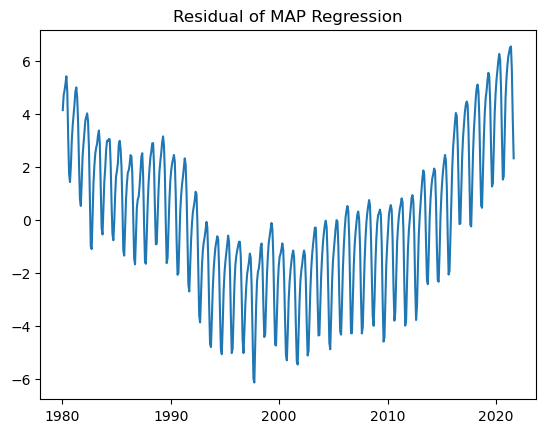

In [9]:
g_obs = y - X @ mu_pos
plt.plot(t, g_obs)
plt.title("Residual of MAP Regression")

In [103]:
def Gaussian_Process(cov_kernel, inputs, random_samples):
    K = cov_kernel(inputs, inputs)
    d, V = np.linalg.eigh(K)
    d = np.maximum(d, 1e-14)
    L = V @ np.diag(np.sqrt(d))
    f = L @ random_samples
    return f


In [104]:
def sum_exp_squared_kernel(theta, sigma, tau, phi, eta, zeta):
    return lambda s,t: theta**2 * np.exp(-2 * np.sin(np.pi * (s.reshape(-1,1) - t.reshape(1,-1)) / tau)**2 / sigma**2) + phi**2 * np.exp(-(s.reshape(-1,1) - t.reshape(1,-1))**2 / 2 / eta**2) + zeta**2 * np.equal(s.reshape(-1,1), t.reshape(1,-1))

In [105]:
def plot_random_functions(domain, kernels, random_samples, title_name, param_name, params):
    fs = [Gaussian_Process(kernel, domain, random_samples) for kernel in kernels]

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))  # 2 rows, 3 columns

    # Flatten the axes array for easy iteration
    axes = axes.flatten()

    # Iterate over each subplot and plot data
    for i, ax in enumerate(axes):
        ax.plot(domain, fs[i])
        ax.set_title(f'{param_name} = {params[i]}')
        ax.grid(True)

    fig.suptitle(title_name, fontsize=20, fontweight='bold')

    # Adjust layout
    plt.tight_layout()

    # Display the plots
    plt.show()

In [106]:
def plot_heat_map(domain, kernels, title_name, param_name, params):
    Ks = [kernel(domain, domain) for kernel in kernels]

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))  # 2 rows, 3 columns

    # Flatten the axes array for easy iteration
    axes = axes.flatten()

    # Iterate over each subplot and plot data
    for i, ax in enumerate(axes):
        ax.imshow(Ks[i])
        ax.set_title(f'{param_name} = {params[i]}')

    fig.suptitle(title_name, fontsize=20, fontweight='bold')

    # Adjust layout
    plt.tight_layout()

    # Display the plots
    plt.show()

In [107]:
domain = np.linspace(-5, 5, 100)
thetas = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
sigmas = [0.01, 0.1, 0.5, 1.0, 2.0, 3.0]
taus = [0.1, 0.5, 1, 2, 5, 10]
phis = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
etas = [0.01, 0.1, 0.5, 1.0, 2.0, 3.0]
zetas = [0.01, 0.1, 0.5, 1.0, 2.0, 3.0]

np.random.seed(100)
random_samples = np.random.rand(domain.shape[0], 10)
theta_kernels = [sum_exp_squared_kernel(theta, 1.0, 1.0, 1.0, 1.0, 1.0) for theta in thetas]
sigma_kernels = [sum_exp_squared_kernel(1.0, sigma, 1.0, 1.0, 1.0, 1.0) for sigma in sigmas]
tau_kernels = [sum_exp_squared_kernel(1.0, 1.0, tau, 1.0, 1.0, 1.0) for tau in taus]
phi_kernels = [sum_exp_squared_kernel(1.0, 1.0, 1.0, phi, 1.0, 1.0) for phi in phis]
eta_kernels = [sum_exp_squared_kernel(1.0, 1.0, 1.0, 1.0, eta, 1.0) for eta in etas]
zeta_kernels = [sum_exp_squared_kernel(1.0, 1.0, 1.0, 1.0, 1.0, zeta) for zeta in zetas]

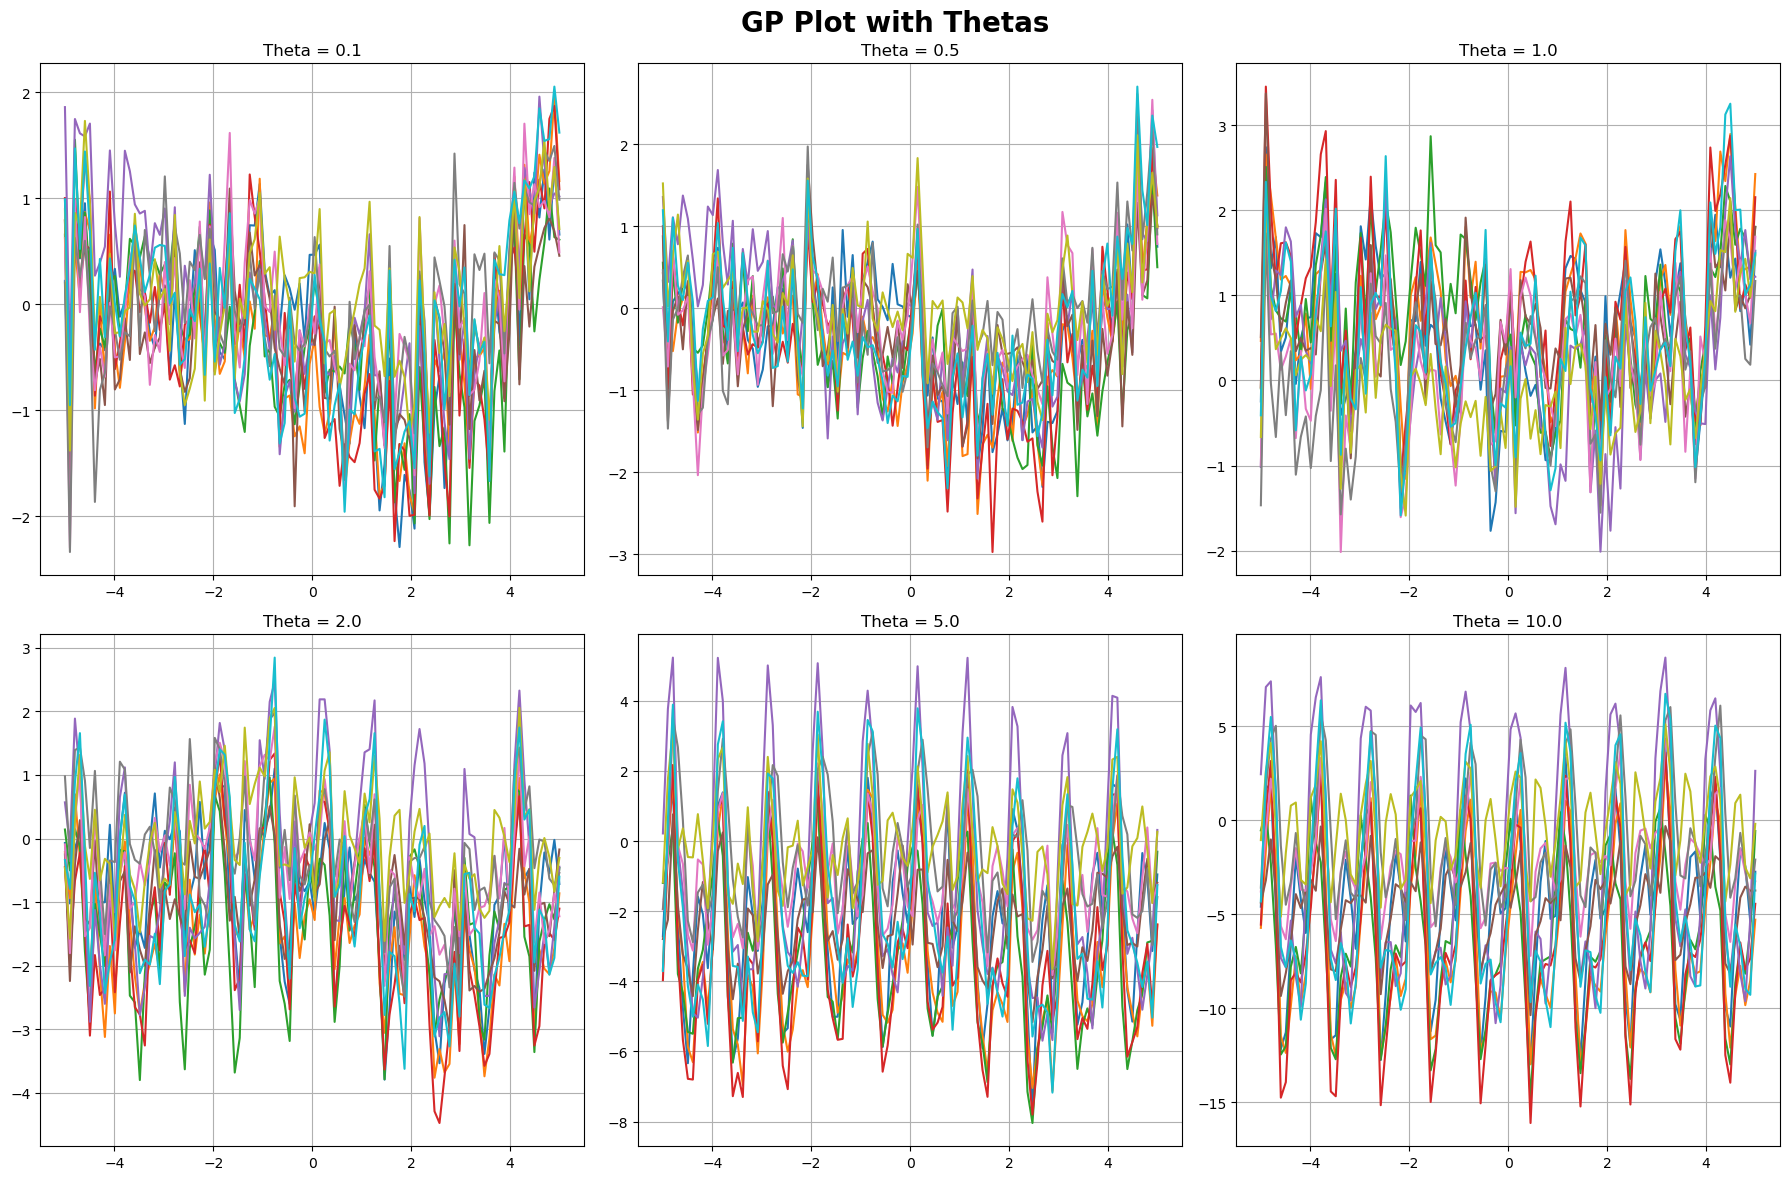

In [108]:
plot_random_functions(domain, theta_kernels, random_samples, 'GP Plot with Thetas', 'Theta', thetas)

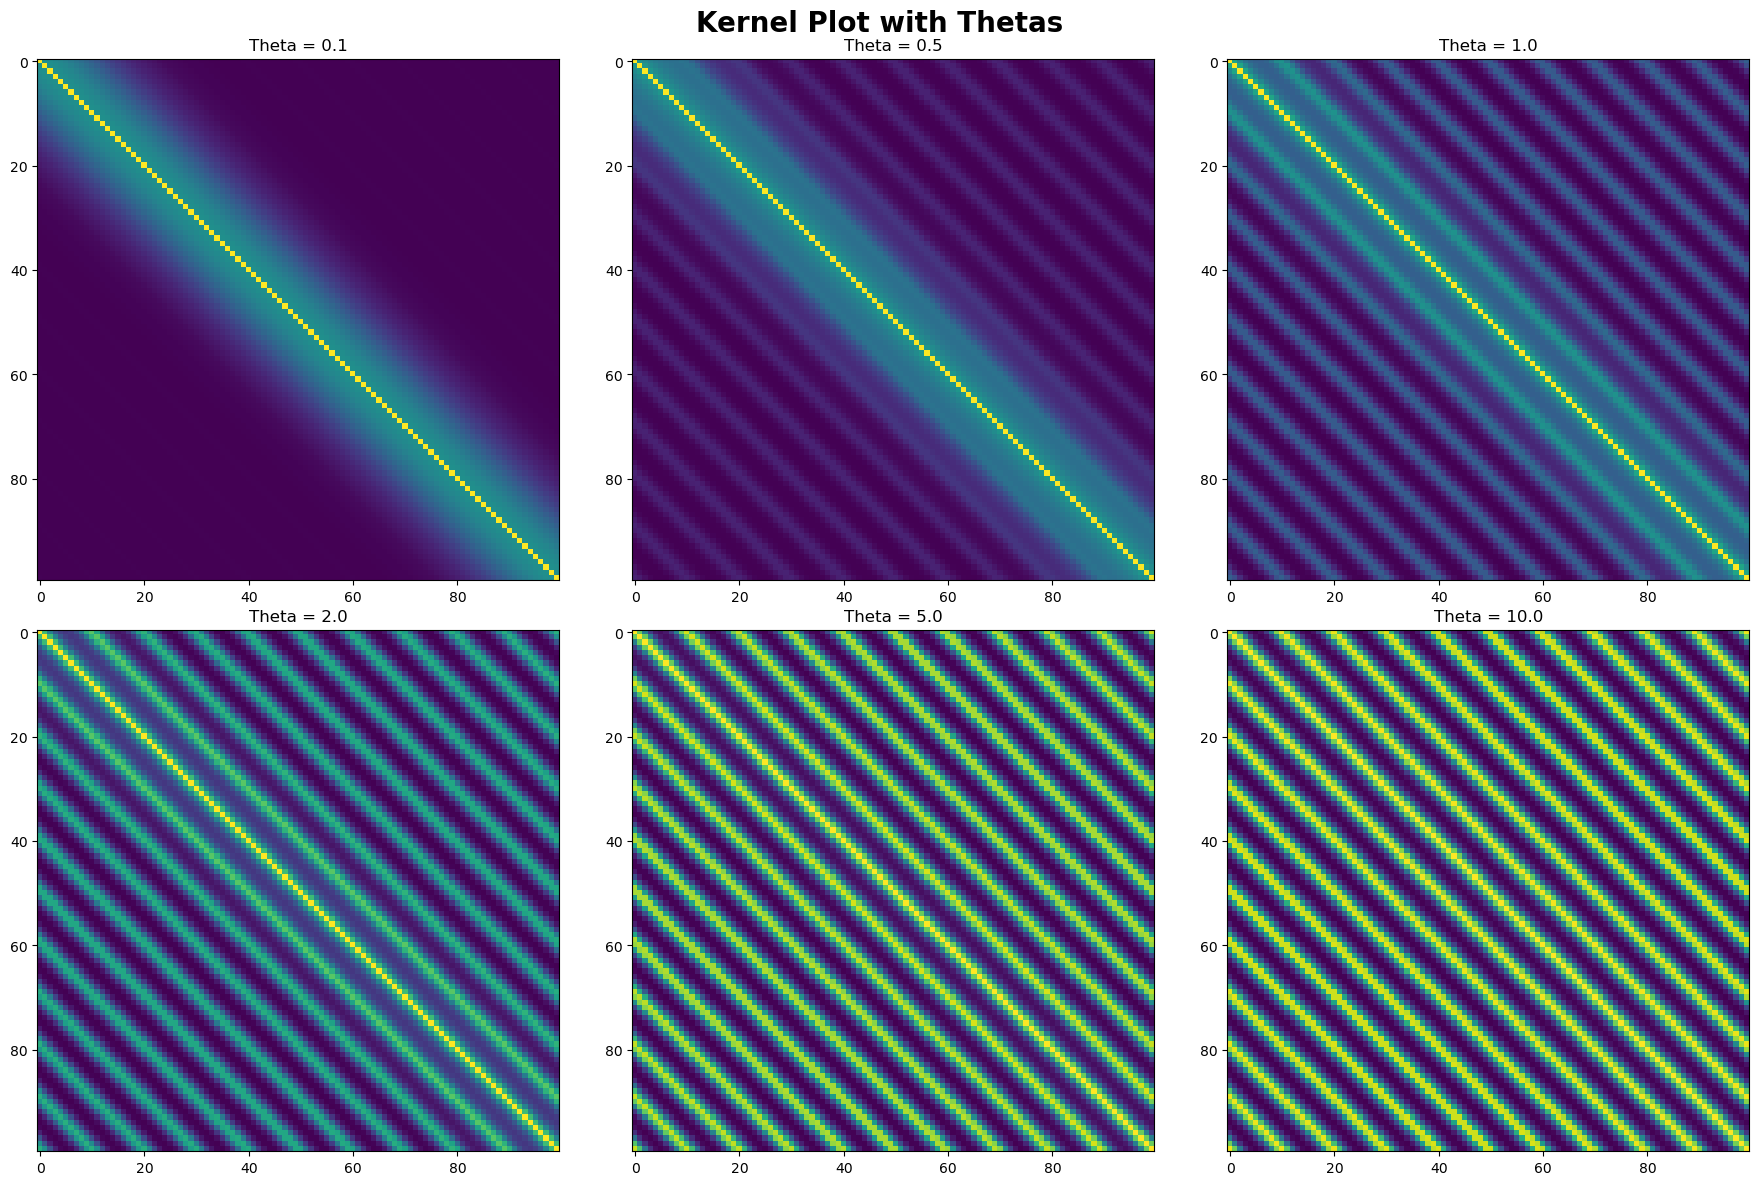

In [109]:
plot_heat_map(domain, theta_kernels, 'Kernel Plot with Thetas', 'Theta', thetas)

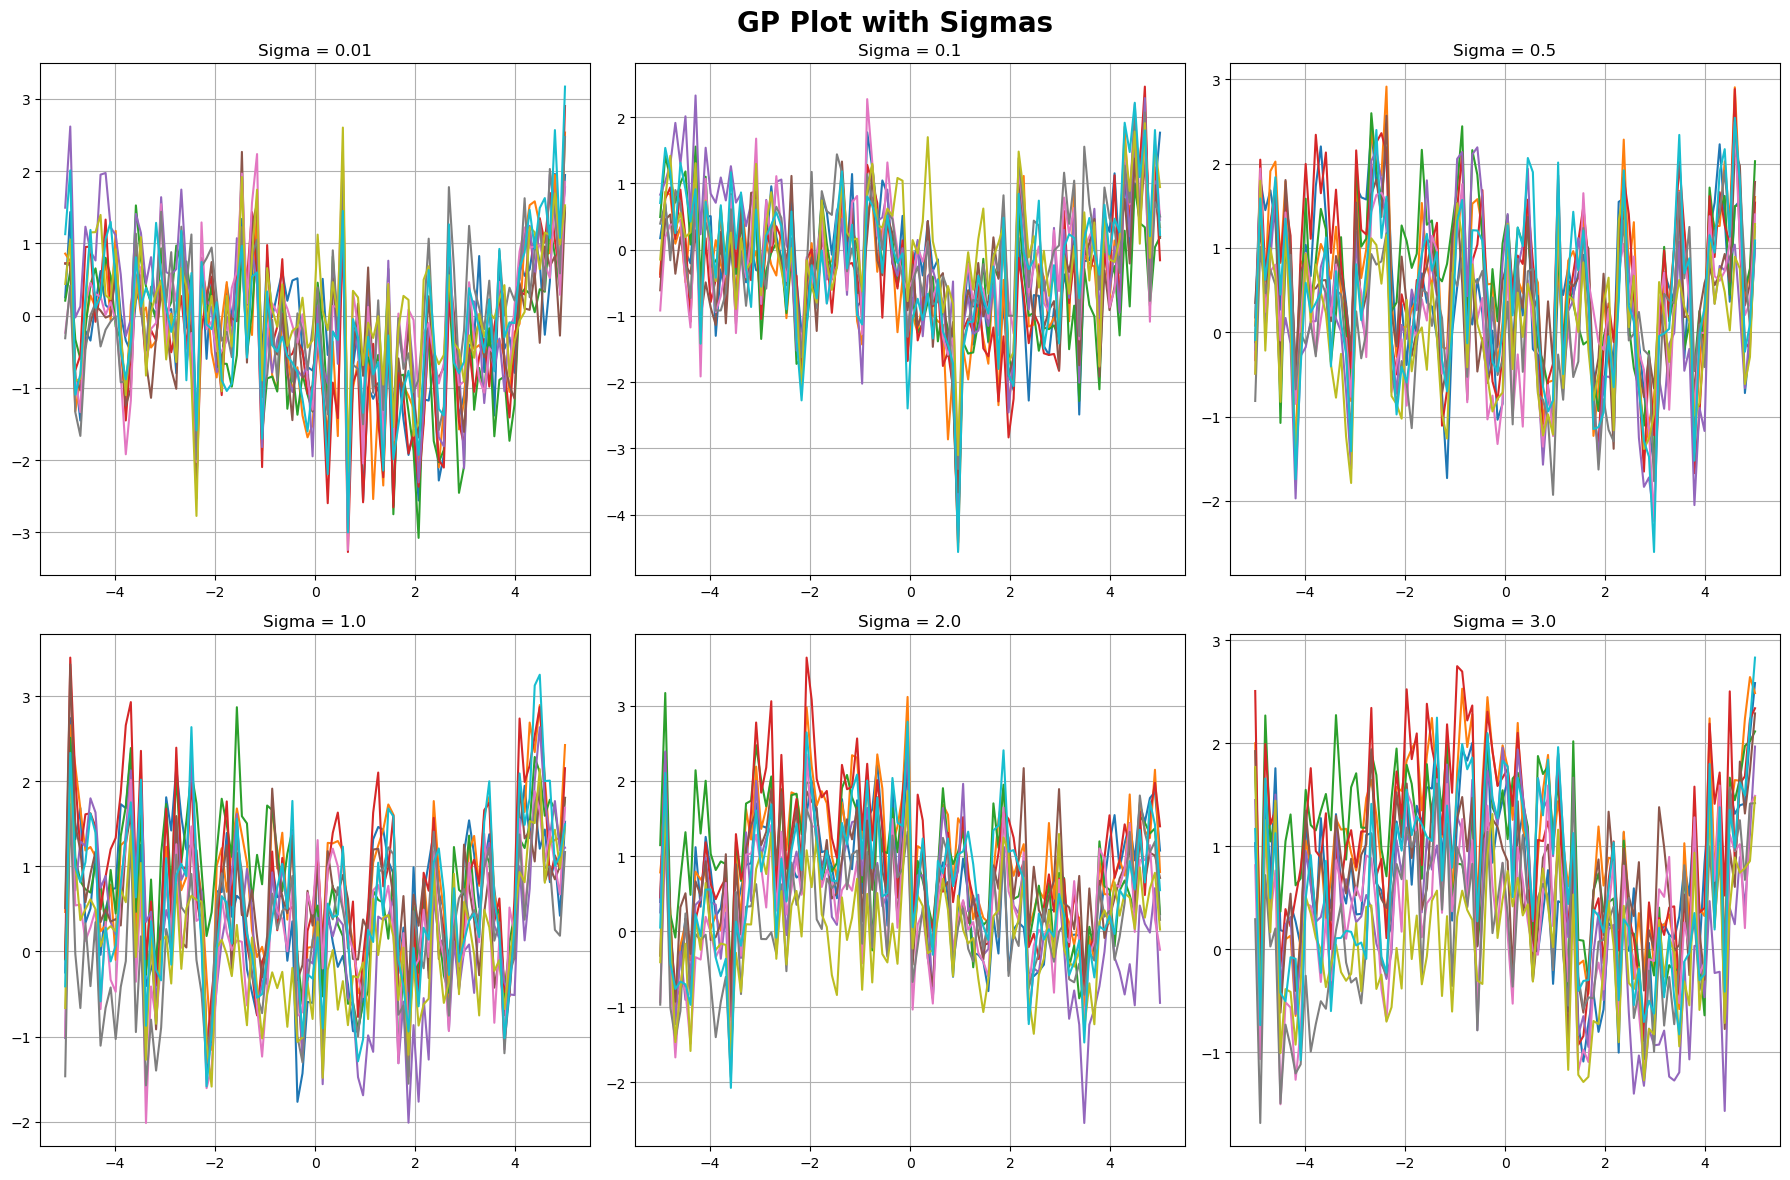

In [110]:
plot_random_functions(domain, sigma_kernels, random_samples, 'GP Plot with Sigmas', 'Sigma', sigmas)

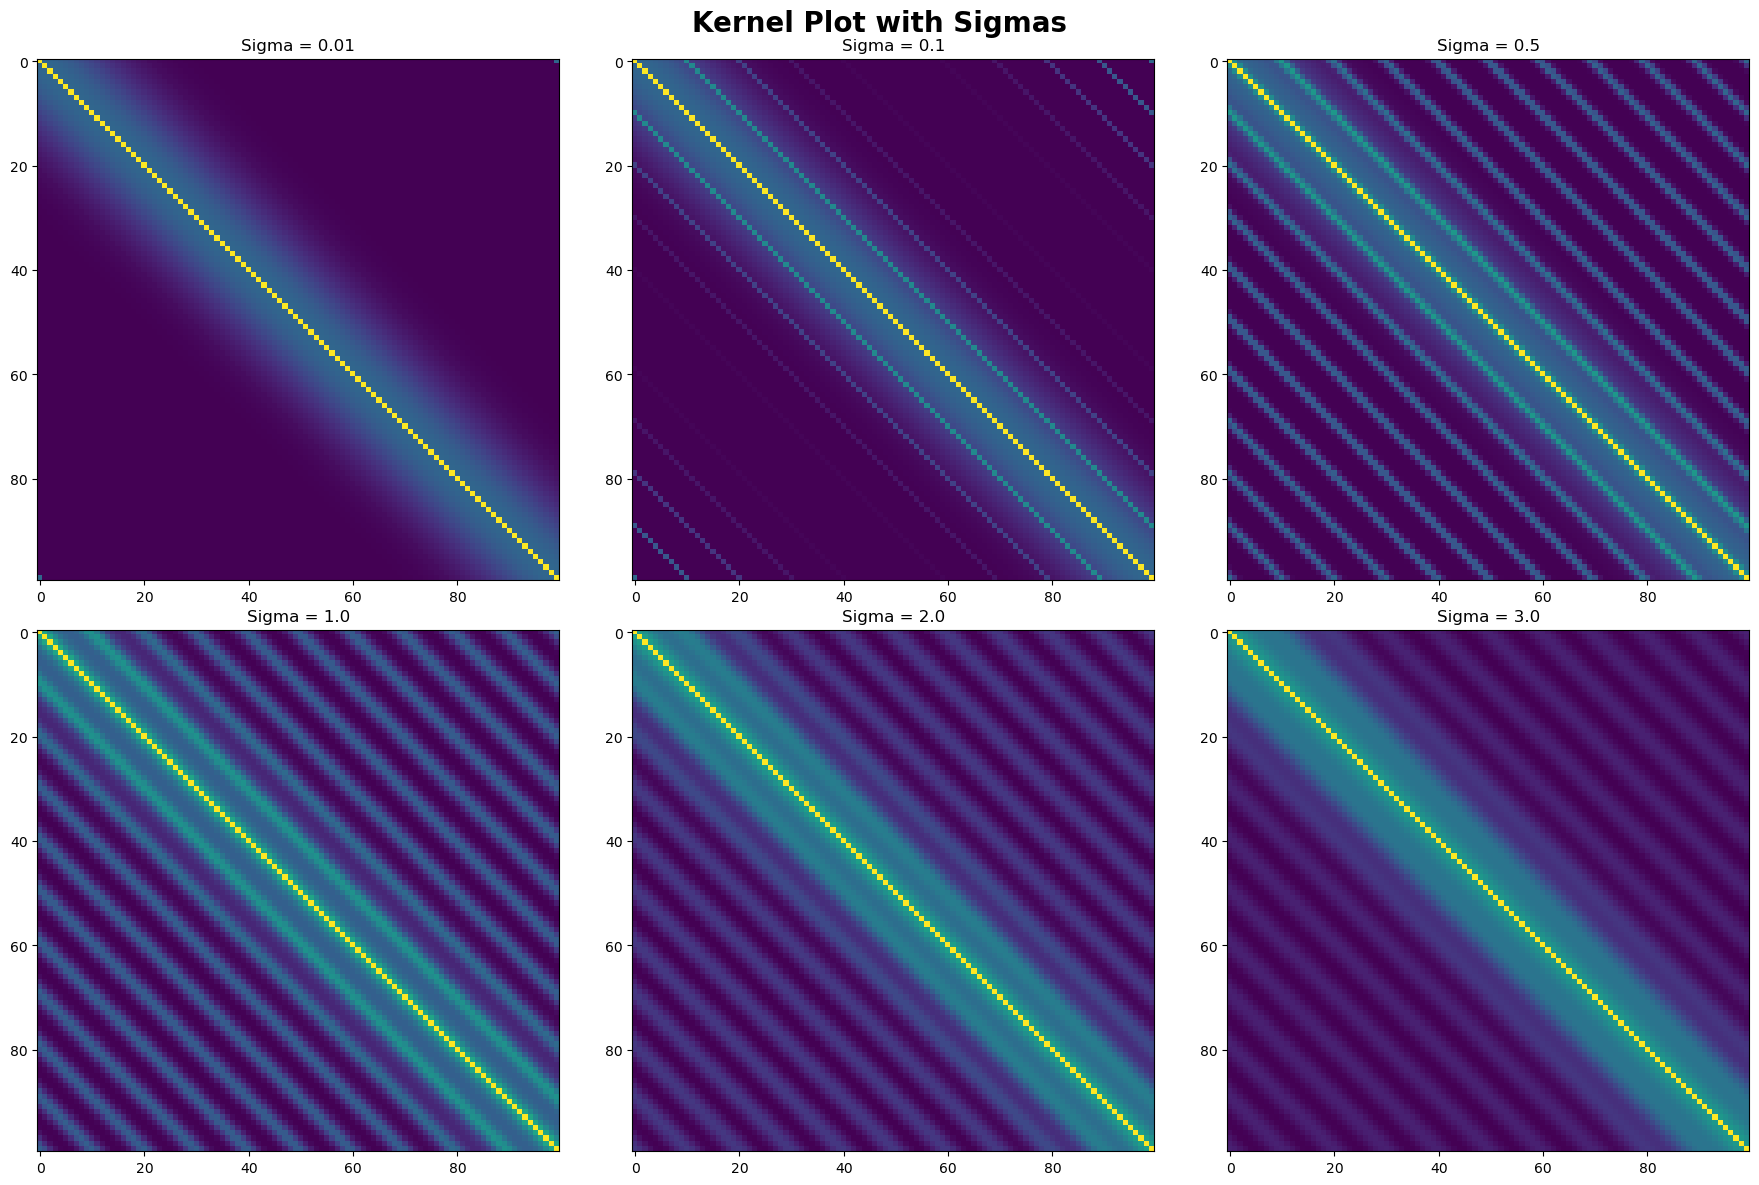

In [111]:
plot_heat_map(domain, sigma_kernels, 'Kernel Plot with Sigmas', 'Sigma', sigmas)

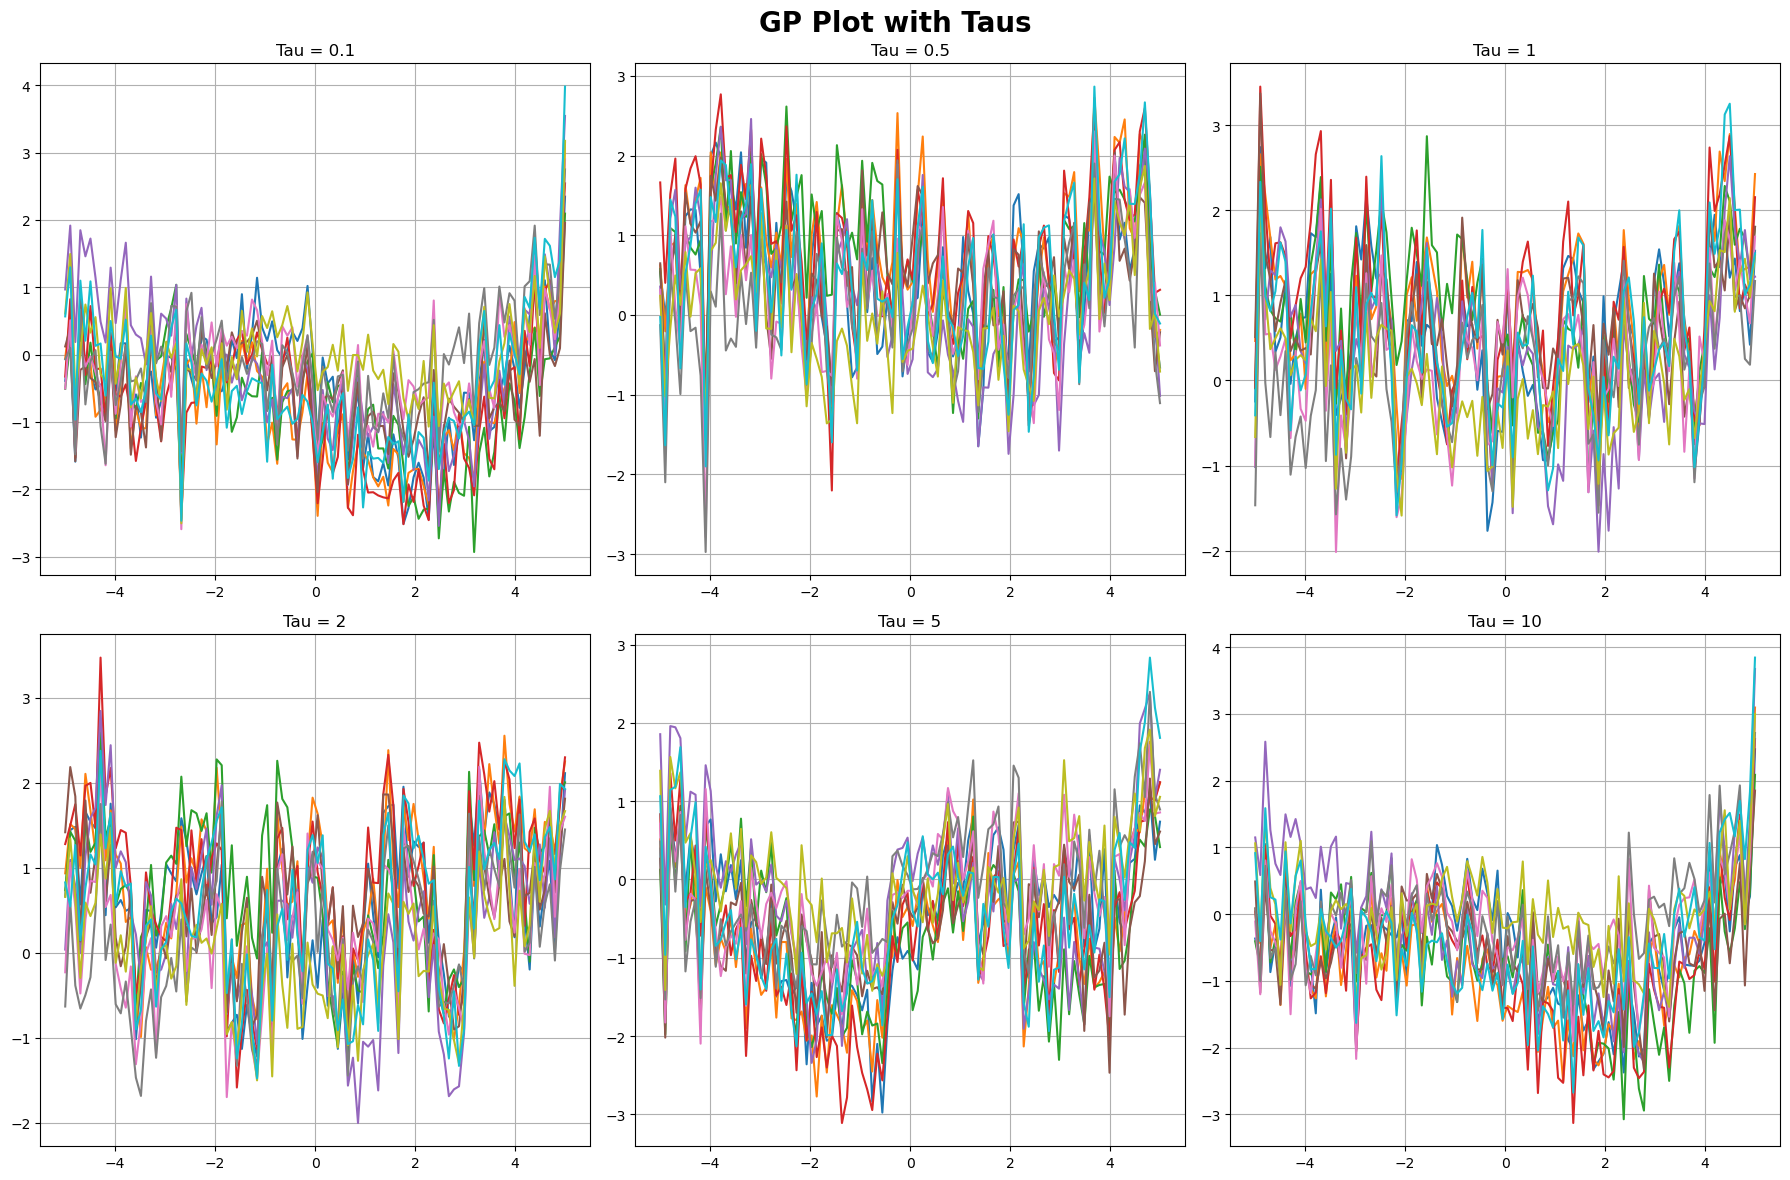

In [112]:
plot_random_functions(domain, tau_kernels, random_samples, 'GP Plot with Taus', 'Tau', taus)

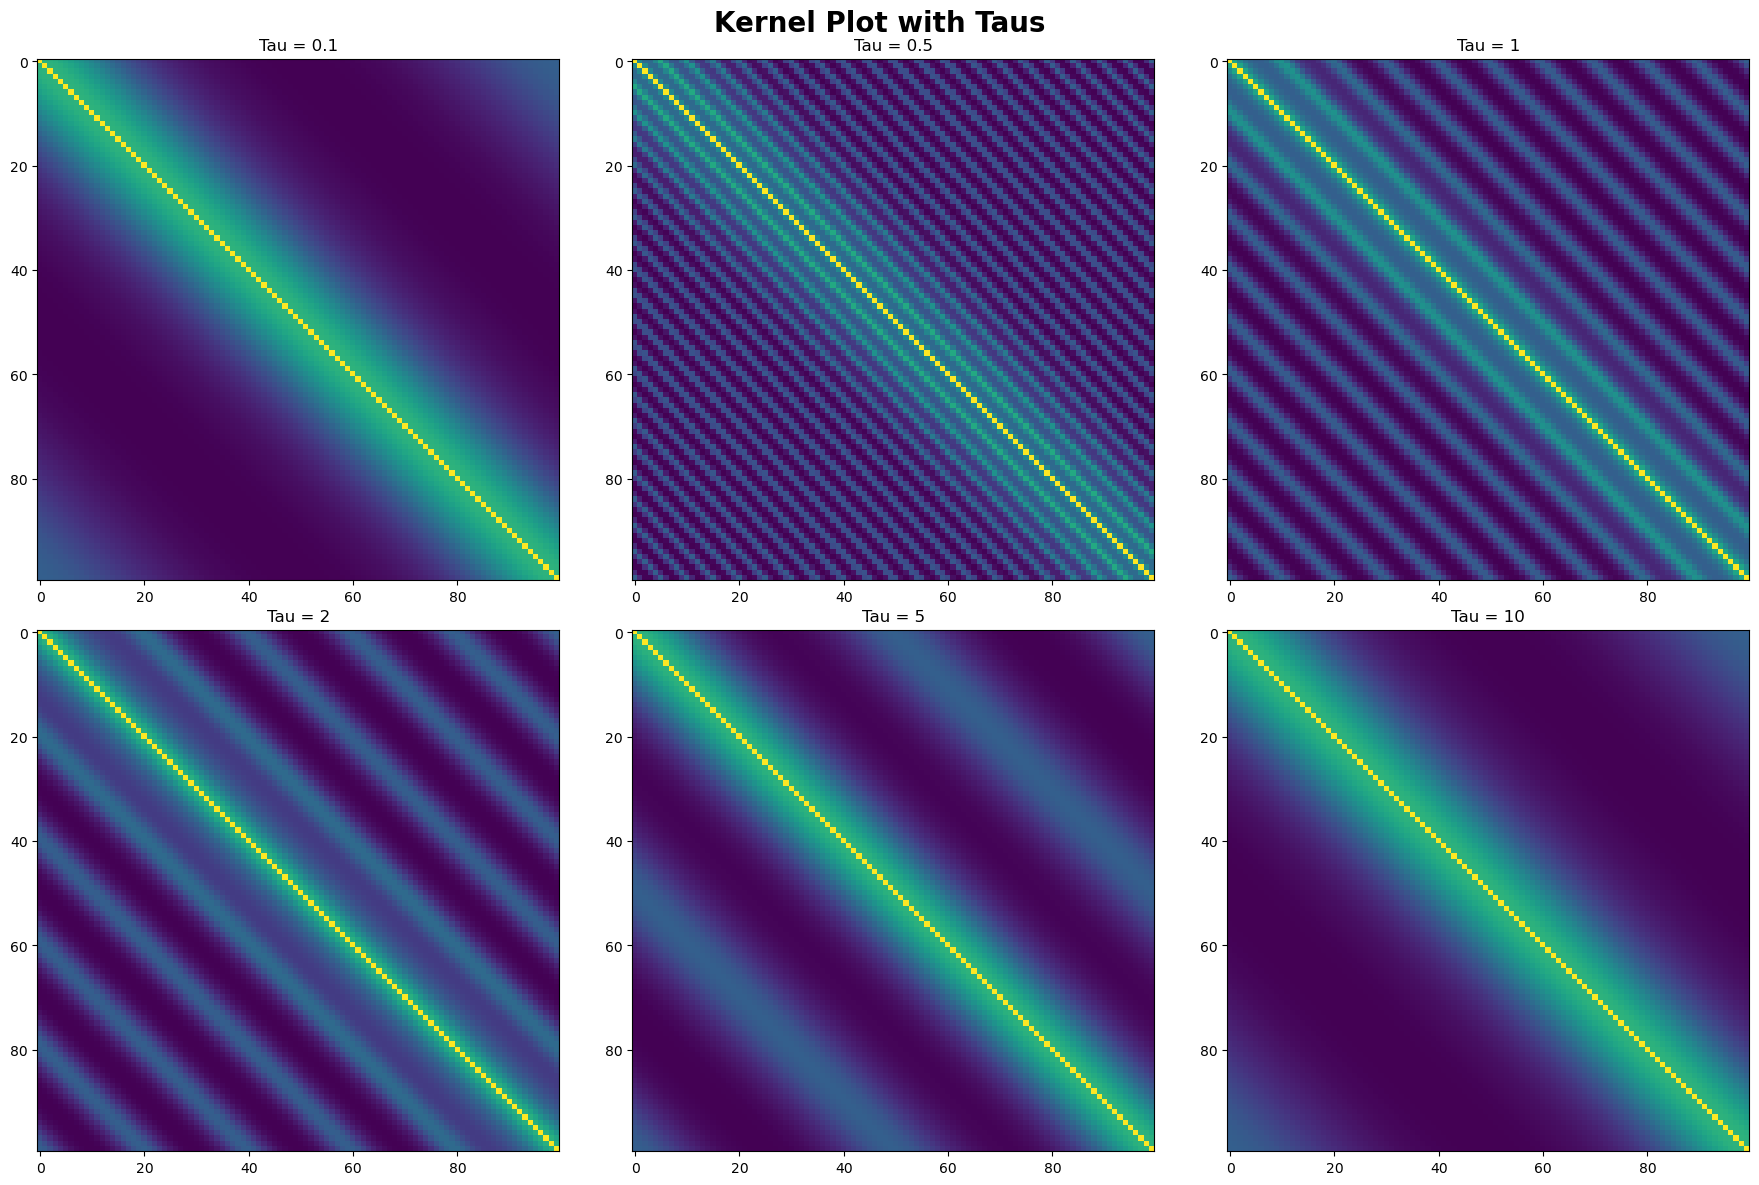

In [113]:
plot_heat_map(domain, tau_kernels, 'Kernel Plot with Taus', 'Tau', taus)

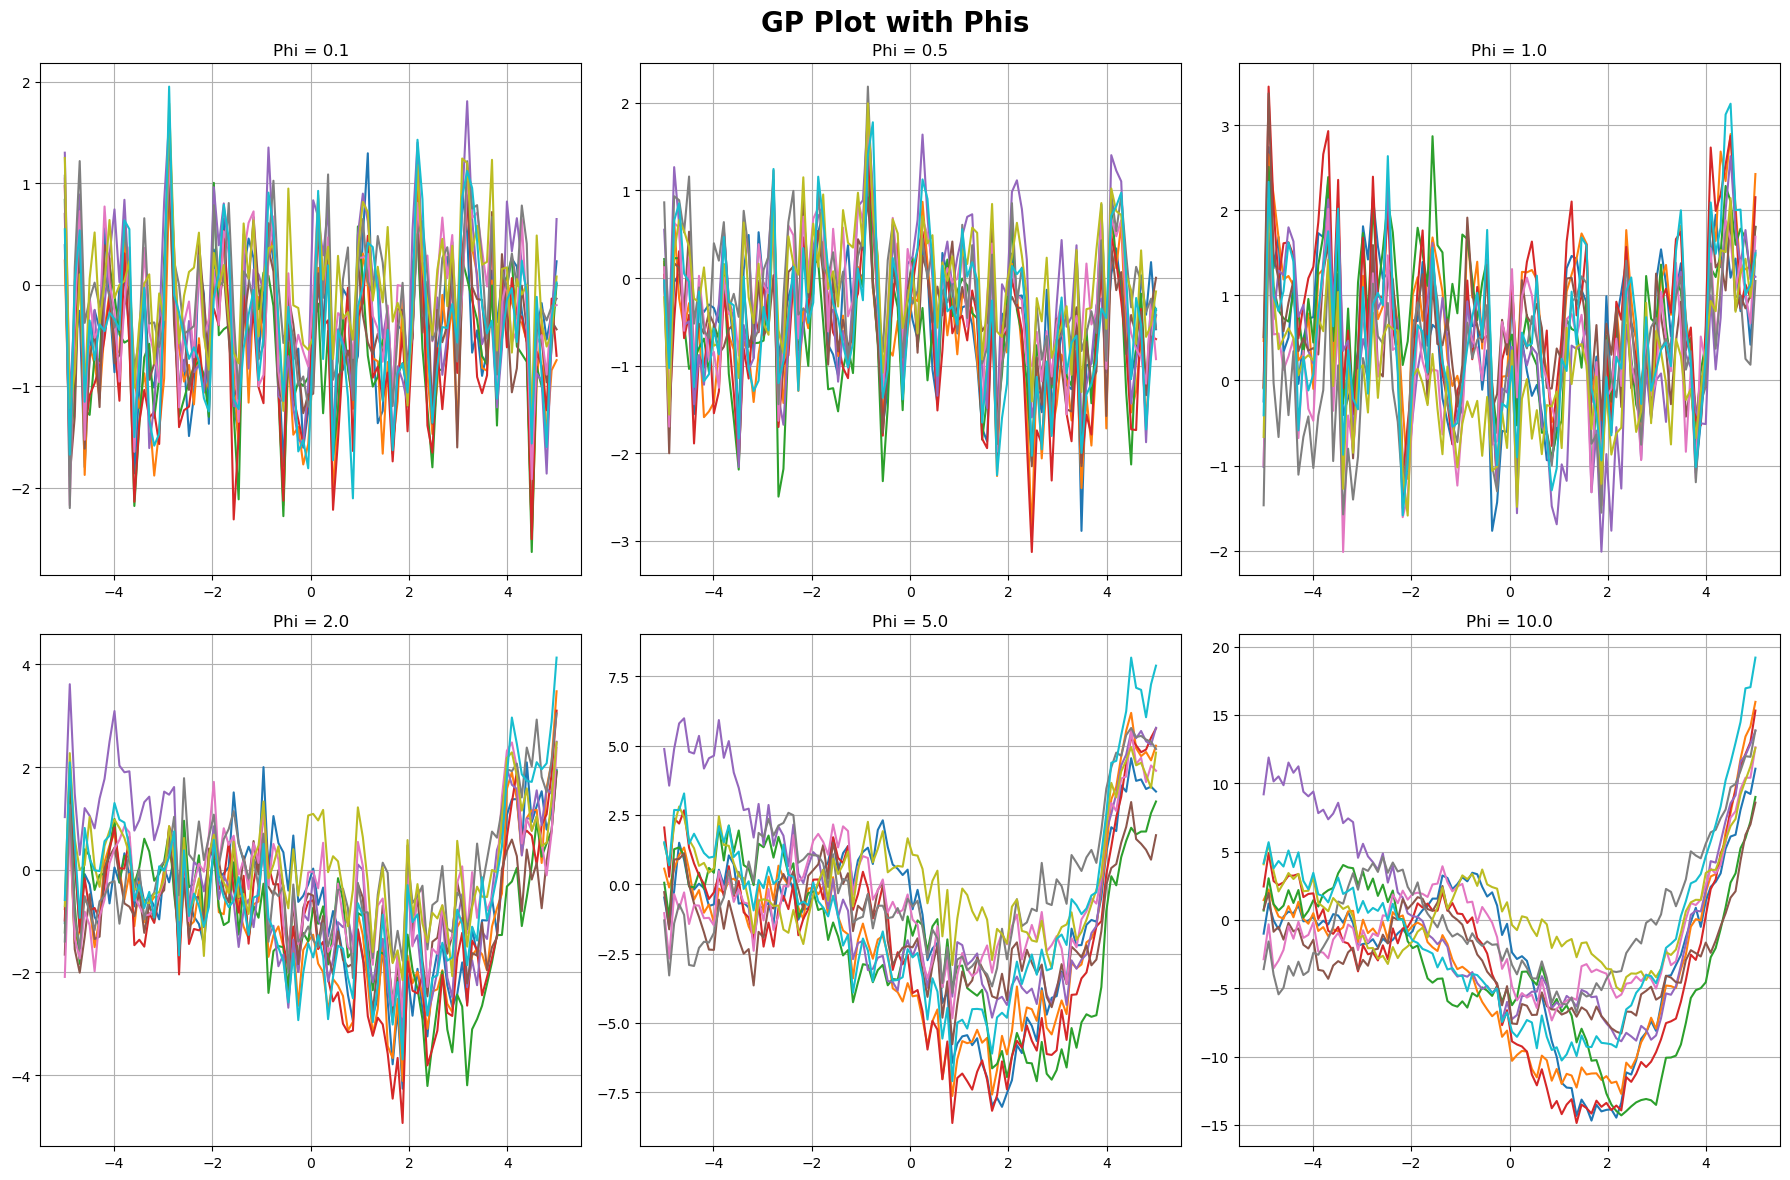

In [114]:
plot_random_functions(domain, phi_kernels, random_samples, 'GP Plot with Phis', 'Phi', phis)

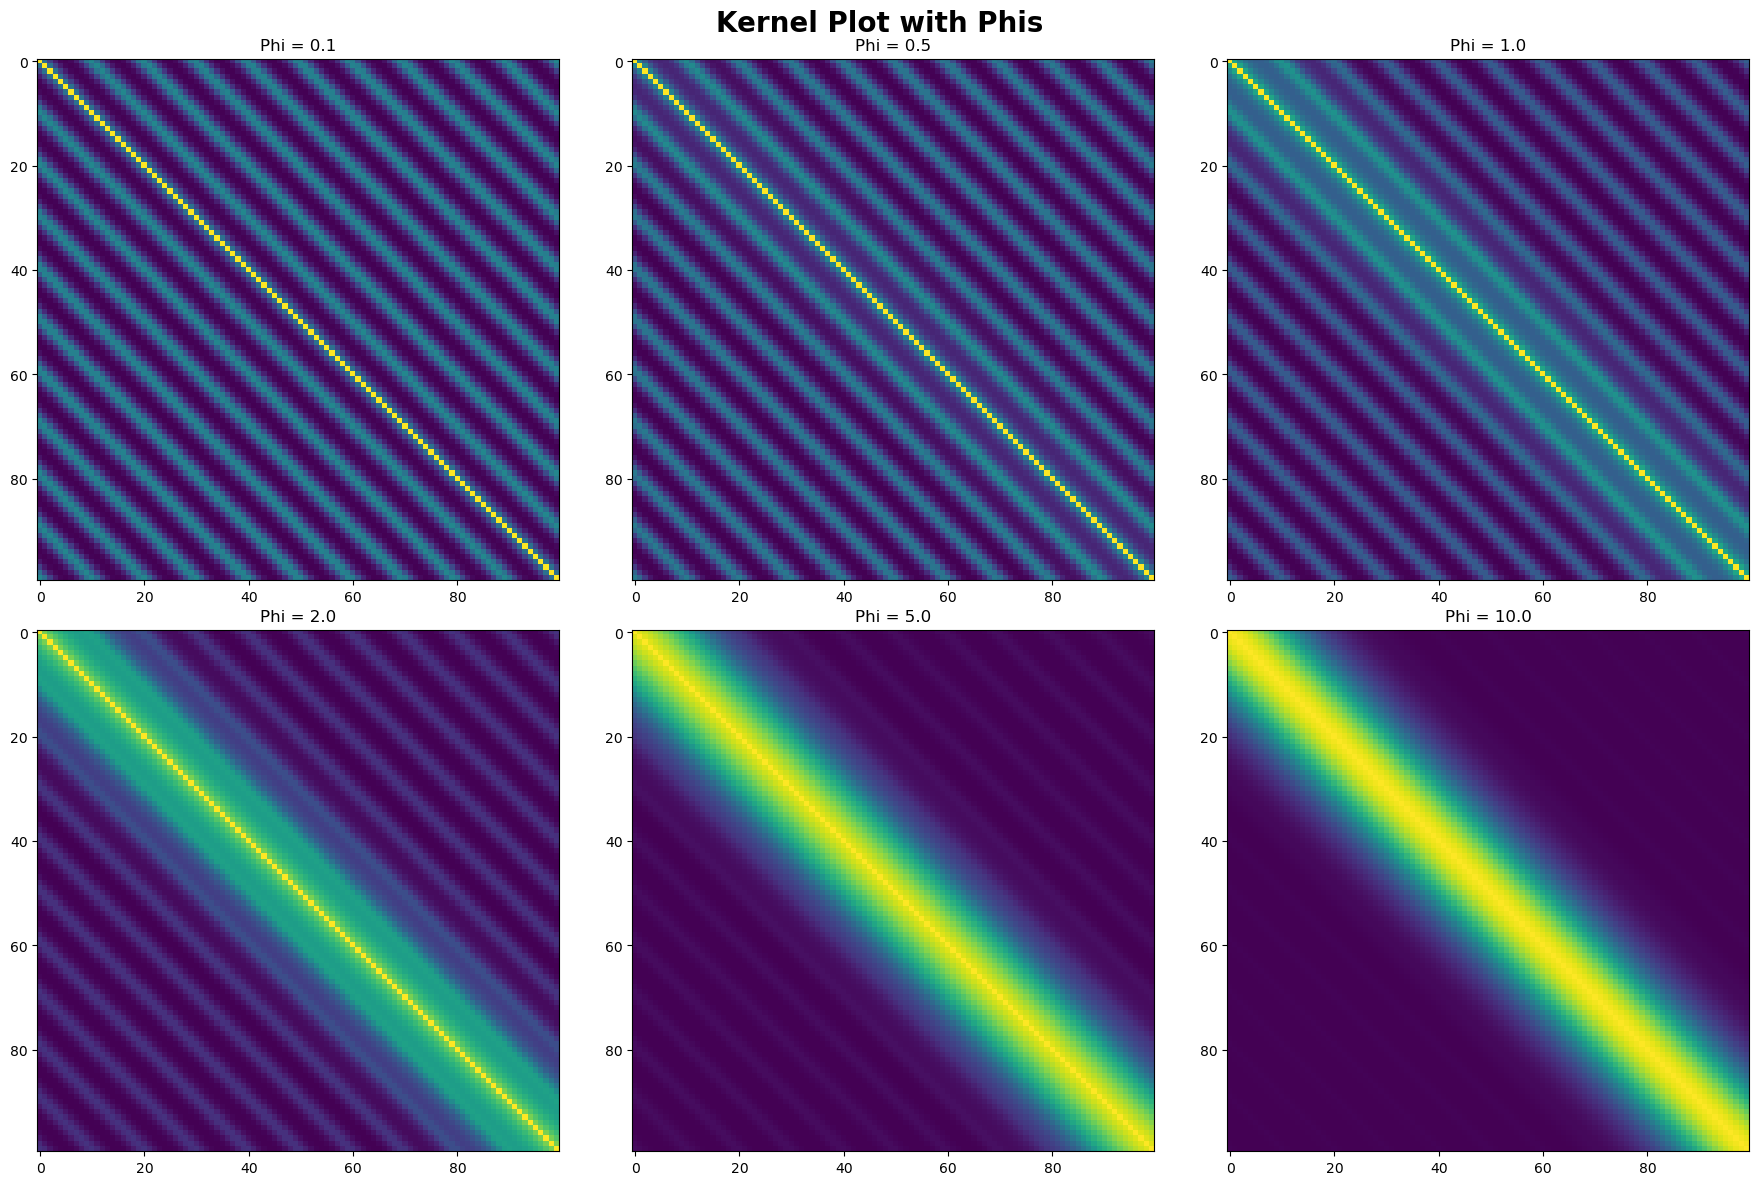

In [115]:
plot_heat_map(domain, phi_kernels, 'Kernel Plot with Phis', 'Phi', phis)

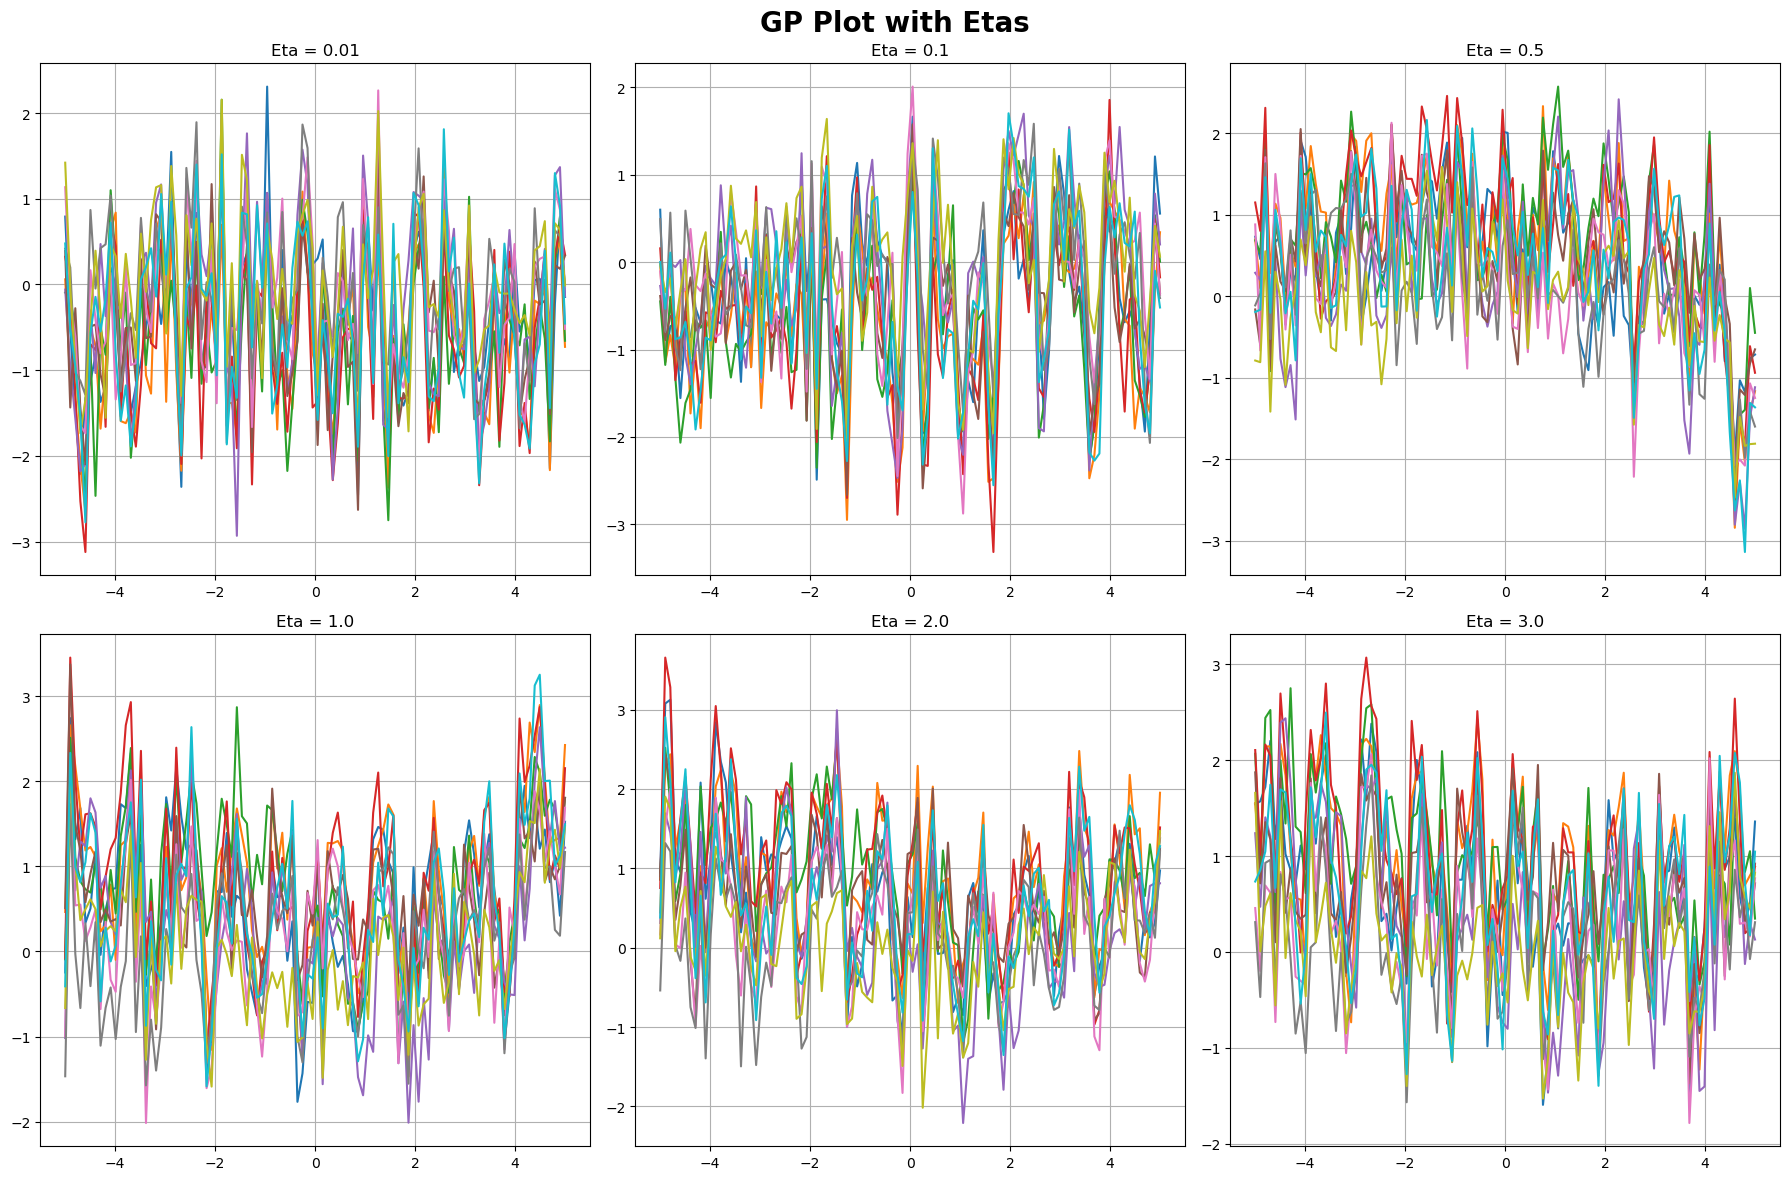

In [116]:
plot_random_functions(domain, eta_kernels, random_samples, 'GP Plot with Etas', 'Eta', etas)

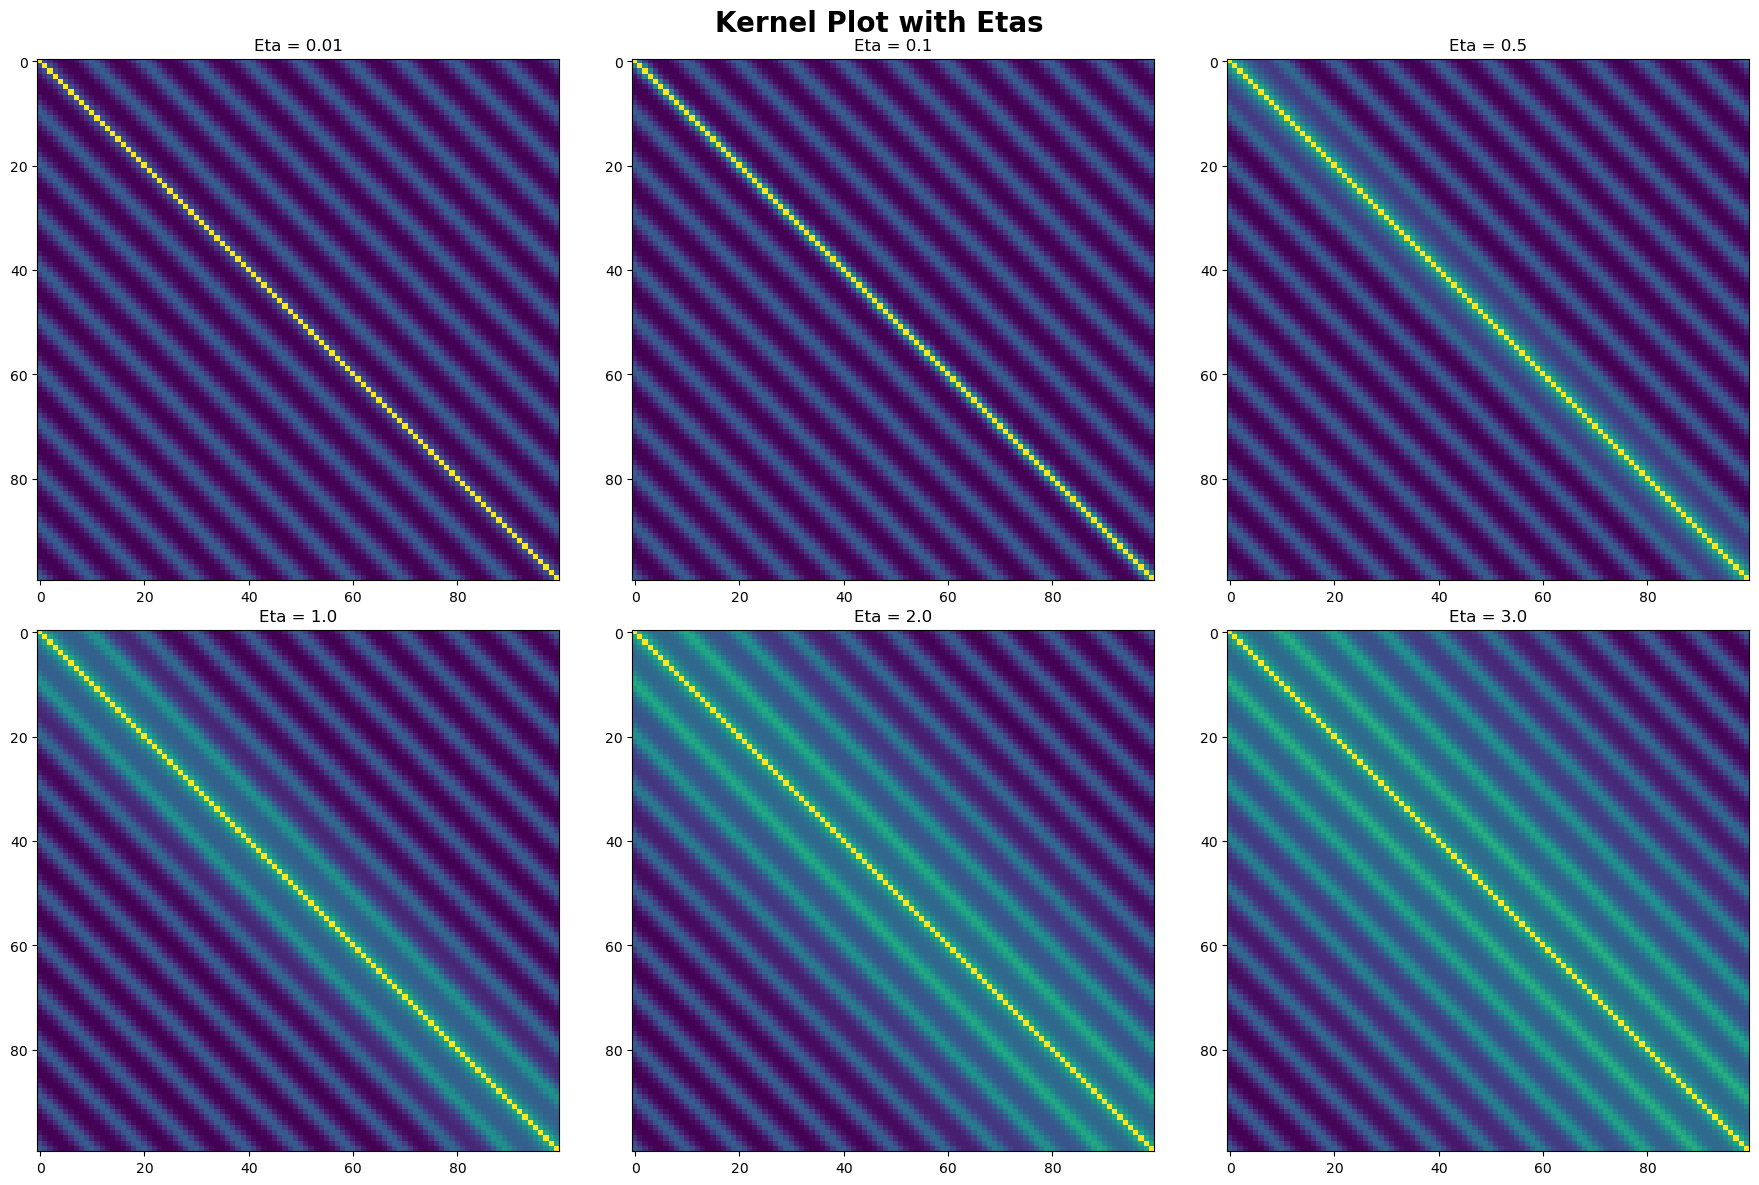

In [117]:
plot_heat_map(domain, eta_kernels, 'Kernel Plot with Etas', 'Eta', etas)

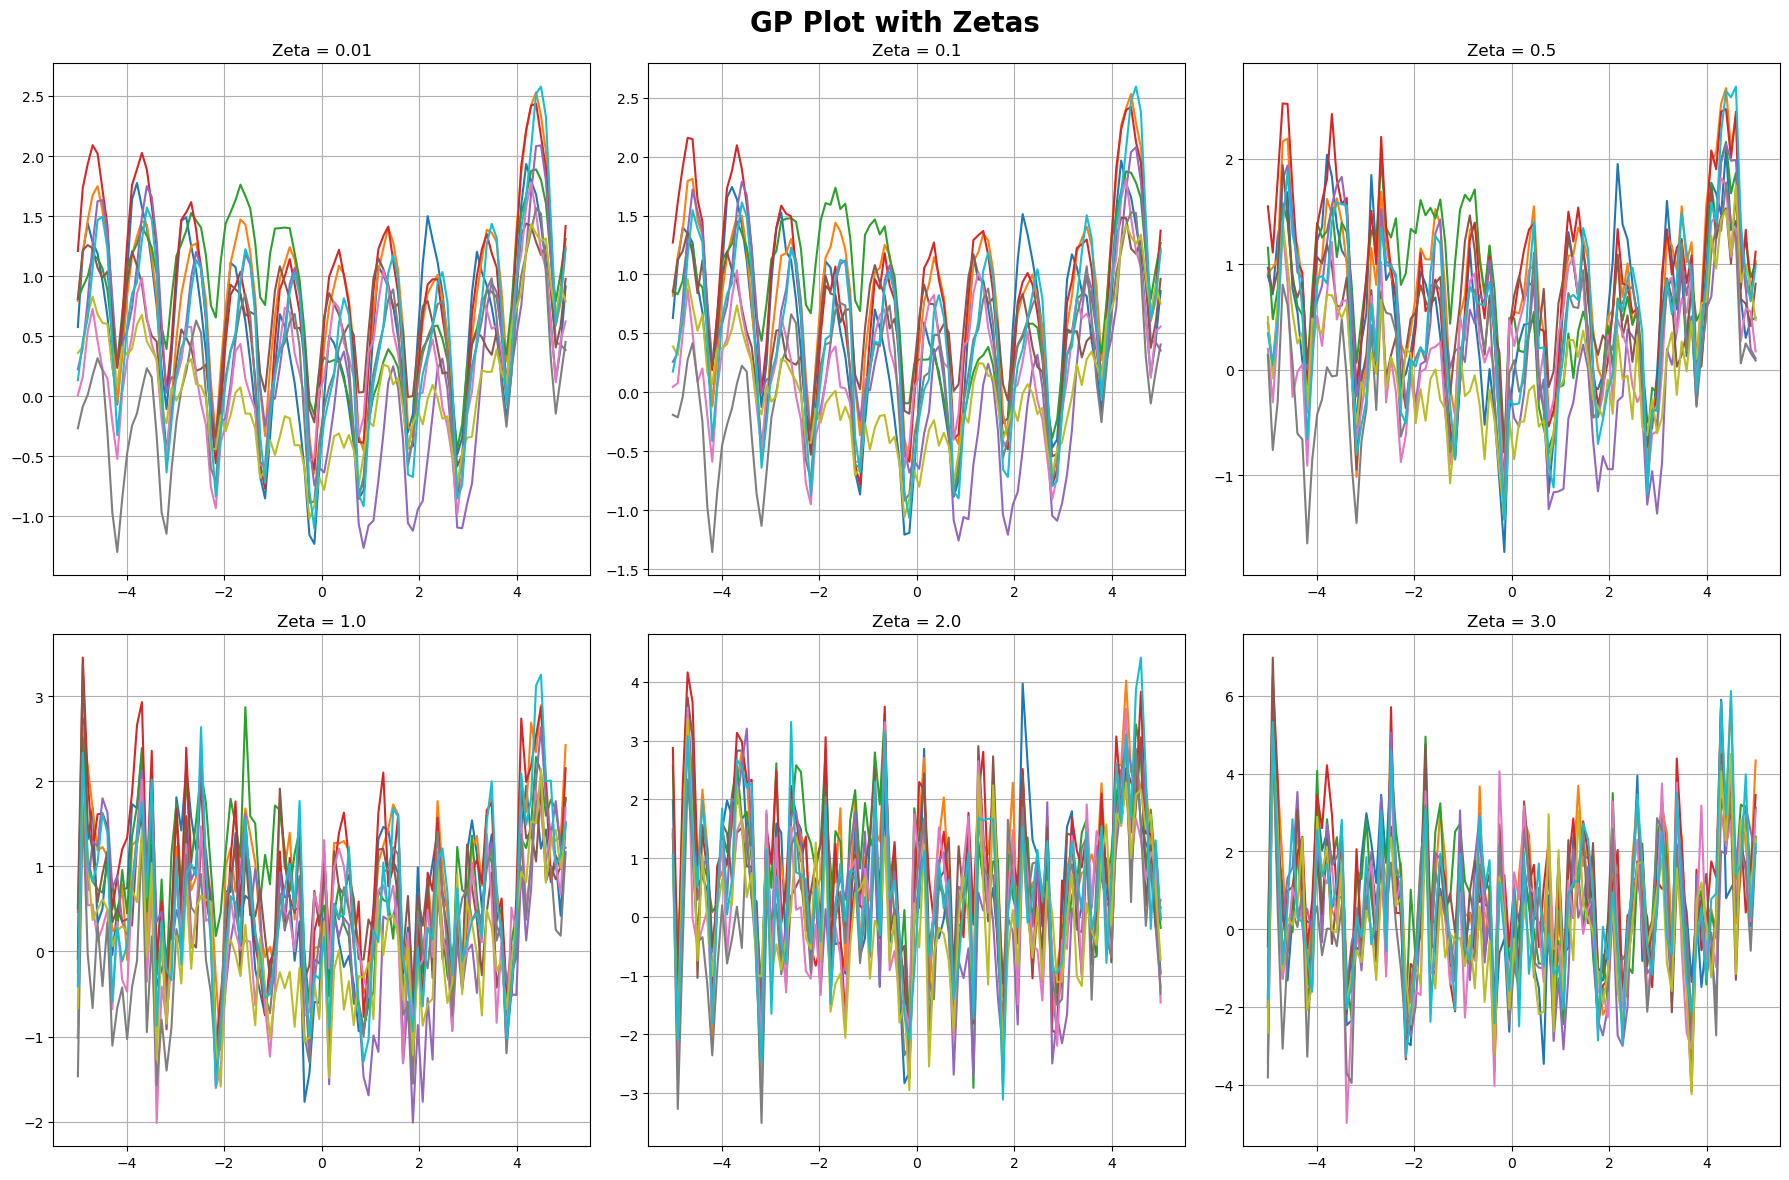

In [118]:
plot_random_functions(domain, zeta_kernels, random_samples, 'GP Plot with Zetas', 'Zeta', zetas)

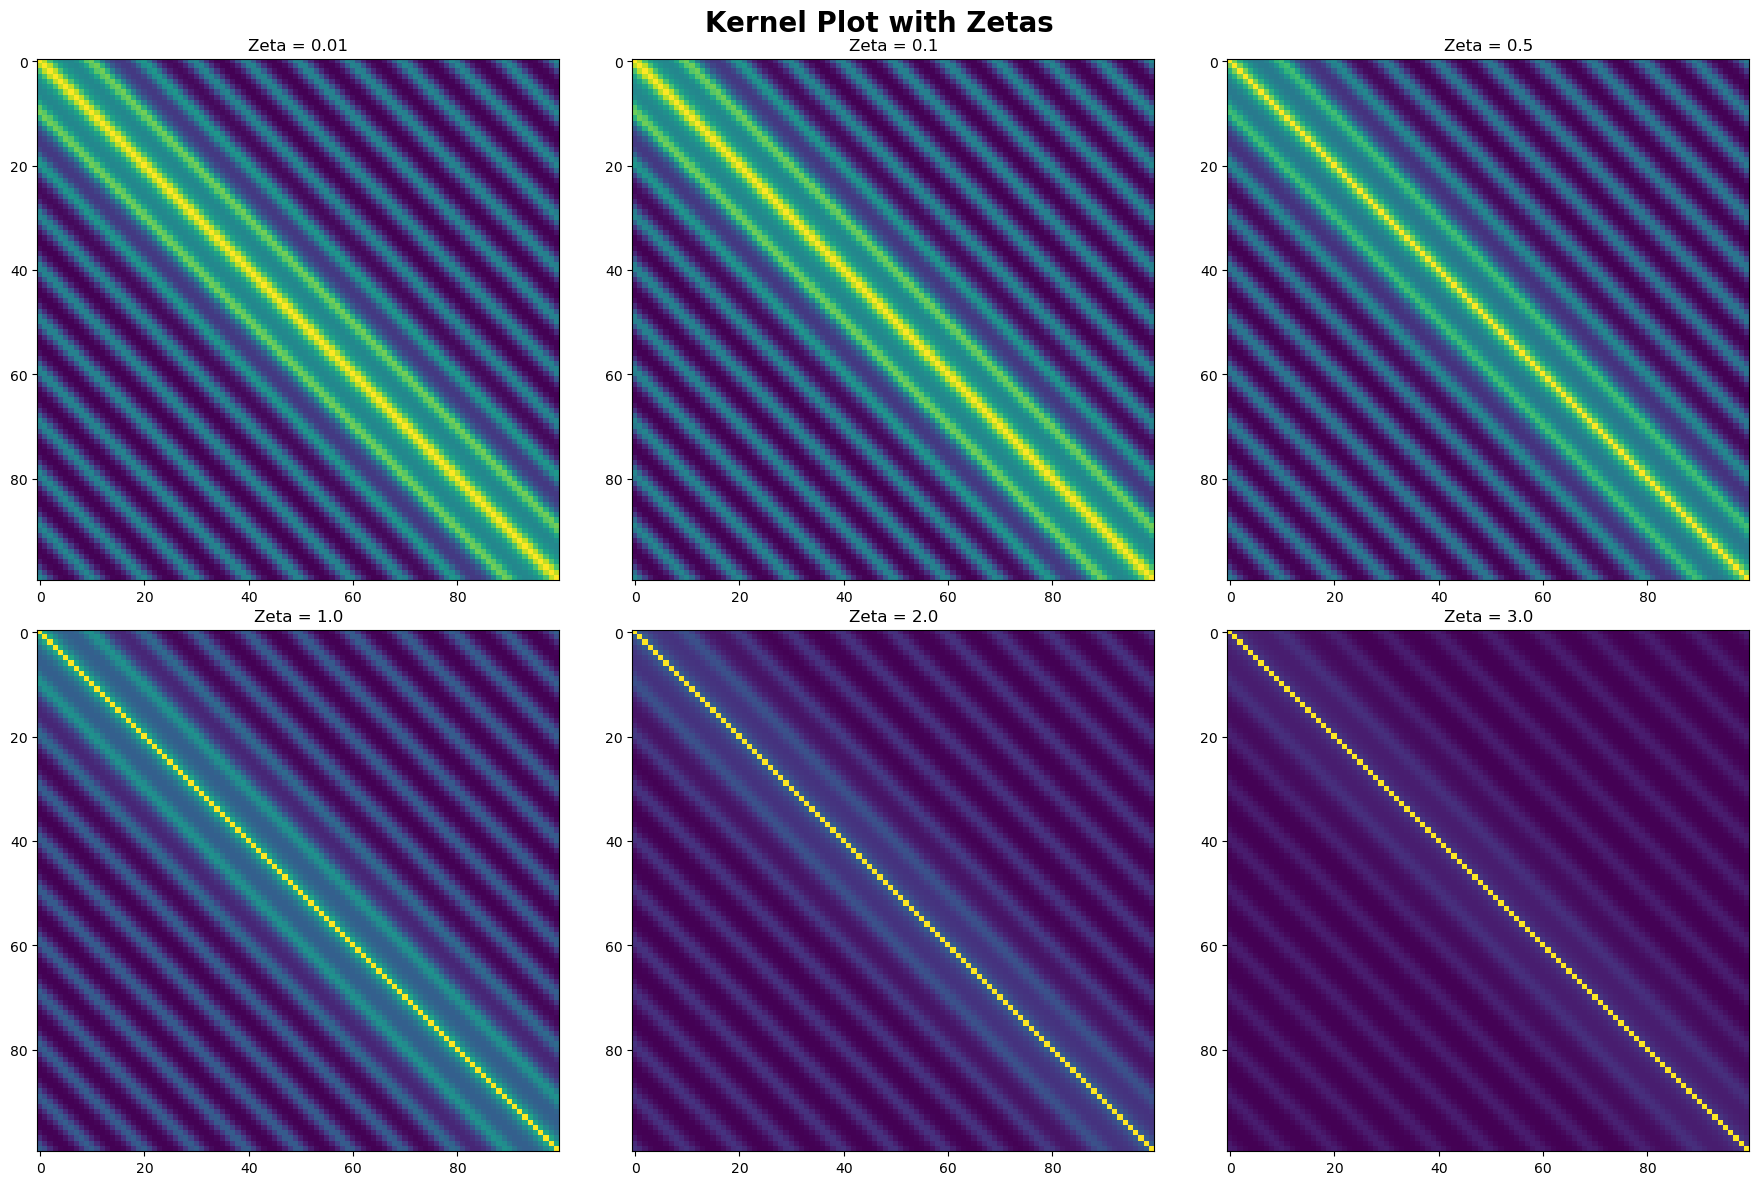

In [119]:
plot_heat_map(domain, zeta_kernels, 'Kernel Plot with Zetas', 'Zeta', zetas)

In [120]:
from statsmodels.graphics.tsaplots import plot_pacf

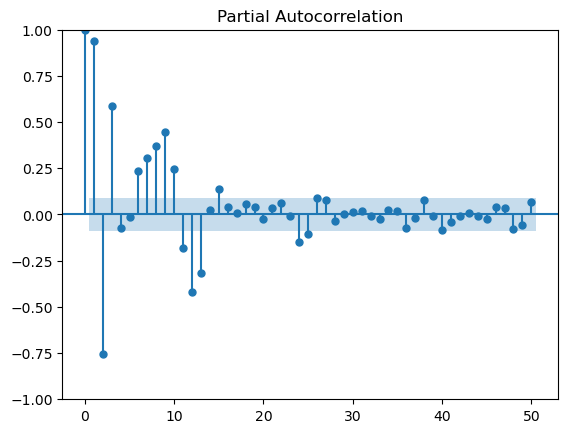

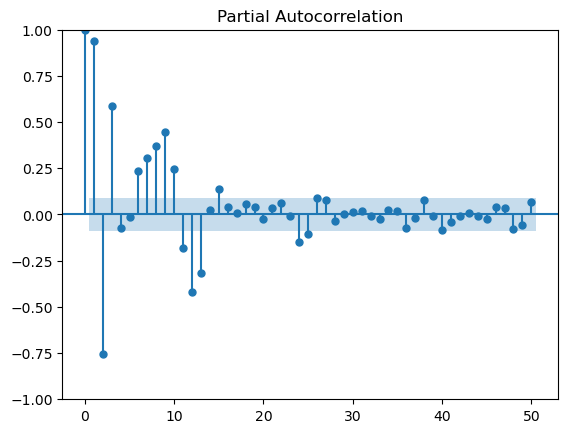

In [121]:
plot_pacf(g_obs, lags=50)

In [122]:
train_data_index = co2_data[(co2_data['year'] < 2007) | ((co2_data['year'] == 2007) & (co2_data['month'] < 9))].index
train_data_x = t[train_data_index]
train_data_y = g_obs[train_data_index]

In [123]:
testing_data_idx = co2_data.iloc[332:]
testing_data_idx = testing_data_idx[testing_data_idx['year'] < 2021].index
testing_data_x = t[testing_data_idx]
testing_data_y = g_obs[testing_data_idx]

In [148]:
co2_kernel = sum_exp_squared_kernel(10.0, 0.1, 1.0, 1.0, 2.0, 2.68)

In [149]:
KXX = co2_kernel(train_data_x, train_data_x)
KxX = co2_kernel(testing_data_x, train_data_x)
KXX_inverse = np.linalg.inv(KXX)
Kxx = co2_kernel(testing_data_x, testing_data_x)
mean = KxX @ (KXX_inverse @ train_data_y)
cov = Kxx - KxX @ KXX_inverse @ KxX.T
std = np.sqrt(np.diag(cov))

In [150]:
f_train = y[train_data_index]
f_test = y[testing_data_idx]

regression_part = X @ mu_pos
regression_part_testing = regression_part[testing_data_idx]
gp_f = regression_part_testing + mean

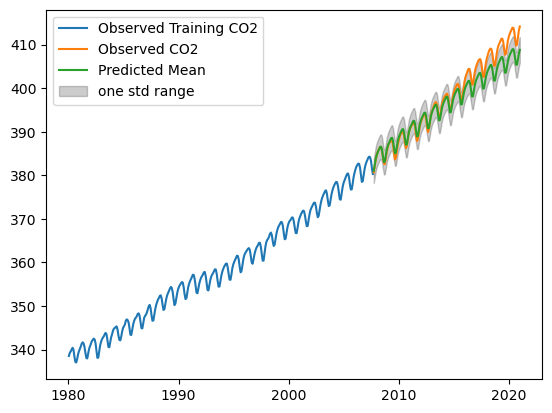

In [151]:
plt.figure()
plt.plot(train_data_x, f_train, label='Observed Training CO2')
plt.plot(testing_data_x, f_test, label='Observed CO2')
plt.plot(testing_data_x, gp_f, label='Predicted Mean')
plt.fill_between(testing_data_x, gp_f - std, gp_f + std, color='k', alpha=0.2, label='one std range')
plt.legend()
plt.show()

# Q3

In [2]:
def MeanField(X, mu, sigma, pie, lambda0, maxsteps, tol):
    """
    E step for mean field variational approximation for binary latent factor model

    Input:
    X:          (N, D) np array, data
    mu:         (D, K) np array, means
    sigma:      scalar, variance of data
    pie:        (K,) np array, prior on s
    lambda0:    (N, K) np array, initial values of lambda
    maxsteps:   max iteration
    tol:        tolerance of halting the iteration

    Output:
    lmbda:      (N, K) lambda after iteration
    F:          Free energy in each iteration
    """
    D, K = mu.shape
    mu2 = mu.T @ mu # (K, K)
    mu2_diag = np.diag(mu2)
    mu2_offdiag = mu2 - np.diag(mu2_diag)
    mu_x = X @ mu # (N, K)
    log_pi = np.log(pie.flatten()) # (K, )
    log_one_minus_pi = np.log(1 - pie.flatten()) # (K, )
    log_pi_one_minus_pi = log_pi - log_one_minus_pi # (K, )
    lmbda = lambda0.copy()
    lmbda_mu_cross = np.array([lmbda_row @ mu2_offdiag @ lmbda_row.T for lmbda_row in lmbda])
    F_n = (
        np.sum(lmbda * log_pi_one_minus_pi, axis=1) + np.sum(log_one_minus_pi)  # Prior term
        - np.sum(lmbda * np.log(lmbda) + (1 - lmbda) * np.log(1 - lmbda), axis=1)  # Entropy term
        - 0.5 / sigma**2 * (np.sum(X**2, axis=1) - 2 * np.sum(lmbda * mu_x, axis=1) + lmbda_mu_cross.flatten() + np.sum(lmbda * mu2_diag[None,:], axis=1))  # Likelihood term
        - D / 2 * np.log(2 * np.pi * sigma**2)  # Normalisation term
    )
    F = np.sum(F_n)
    Fs = [F]
    for _ in range(maxsteps):
        old_F = F
        for k in range(K):
            lmbda_mu_without_k = lmbda @ mu2[:, k] - lmbda[:, k] * mu2[k, k]
            logit_1 = -0.5 / sigma**2 * (mu2[k, k] + 2.0 * lmbda_mu_without_k - 2.0 * mu_x[:, k]) + log_pi_one_minus_pi[k]
            lmbda[:, k] = np.clip(1.0 / (1.0 + np.exp(-logit_1)), 1e-8, 1 - 1e-8)

        lmbda_mu_cross = np.array([lmbda_row @ mu2_offdiag @ lmbda_row.T for lmbda_row in lmbda])
        
        F_n = (
            np.sum(lmbda * log_pi_one_minus_pi, axis=1) + np.sum(log_one_minus_pi)  # Prior term
            - np.sum(lmbda * np.log(lmbda) + (1 - lmbda) * np.log(1 - lmbda), axis=1)  # Entropy term
            - 0.5 / sigma**2 * (np.sum(X**2, axis=1) - 2 * np.sum(lmbda * mu_x, axis=1) + lmbda_mu_cross.flatten() + np.sum(lmbda * mu2_diag[None,:], axis=1))  # Likelihood term
            - D / 2 * np.log(2 * np.pi * sigma**2)  # Normalisation term
        )

        F = np.sum(F_n)
        Fs.append(F)
        if np.abs(F - old_F) < tol:
            break
    return lmbda, Fs
        


In [3]:
def m_step(X, ES, ESS):
    """
    mu, sigma, pie = MStep(X,ES,ESS)

    Inputs:
    -----------------
           X: shape (N, D) data matrix
          ES: shape (N, K) E_q[s]
         ESS: shape (K, K) sum over data points of E_q[ss'] (N, K, K)
                           if E_q[ss'] is provided, the sum over N is done for you.

    Outputs:
    --------
          mu: shape (D, K) matrix of means in p(y|{s_i},mu,sigma)
       sigma: shape (,)    standard deviation in same
         pie: shape (1, K) vector of parameters specifying generative distribution for s
    """
    N, D = X.shape
    if ES.shape[0] != N:
        raise TypeError('ES must have the same number of rows as X')
    K = ES.shape[1]
    if ESS.shape == (N, K, K):
        ESS = np.sum(ESS, axis=0)
    if ESS.shape != (K, K):
        raise TypeError('ESS must be square and have the same number of columns as ES')

    mu = np.dot(np.dot(np.linalg.inv(ESS), ES.T), X).T
    sigma = np.sqrt((np.trace(np.dot(X.T, X)) + np.trace(np.dot(np.dot(mu.T, mu), ESS))
                     - 2 * np.trace(np.dot(np.dot(ES.T, X), mu))) / (N * D))
    pie = np.mean(ES, axis=0, keepdims=True)
    
    return mu, sigma, pie

In [4]:
def LearnBinFactors(X, K, iterations, sigma0=None, tol=1.0e-8):
    """
    EM algorithm

    Input:
    X: (N, D) data
    K: scalar, number of binary factors
    iterations: scalar, max iterations
    sigma0: scalar, initial value of sigma
    tol: scalar, tolerance of halting the iteration
    """
    N, D = X.shape
    pie_init = np.empty(K); pie_init.fill(0.5)
    mu_init = np.random.randint(0, 2, (D, K))
    if sigma0:
        sigma_init = sigma0
    else:
        sigma_init = 0.5 * K
    lmbda_init = np.tile(pie_init, (N, 1))
    Fs = []
    pie = pie_init.copy()
    mu = mu_init.copy()
    sigma = sigma_init
    lmbda = lmbda_init.copy()
    for _ in range(iterations):
        lmbda, M_Fs = MeanField(X, mu, sigma, pie, lmbda, 100, 1.0e-8)
        Fs.append(M_Fs[-1])
        ES = lmbda
        ESS = np.array([this_lmbda.reshape(-1, 1) * this_lmbda.reshape(1, -1) for this_lmbda in lmbda])
        for n in range(N):
            np.fill_diagonal(ESS[n, :, :], lmbda[n])
        mu, sigma, pie = m_step(X, ES, ESS)
        if len(Fs) > 1 and np.abs(Fs[-1] - Fs[-2]) < tol:
            break
    return mu, sigma, pie, Fs


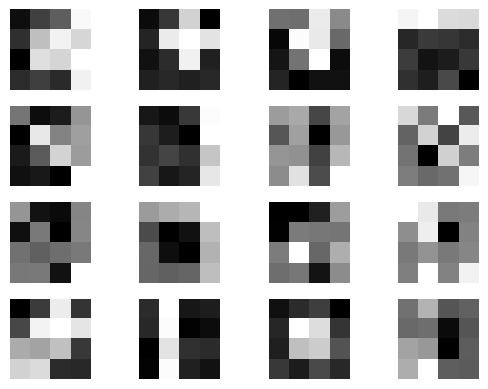

In [5]:
N=400  # number of data points - you can increase this if you want to
       # learn better features (but it will take longer).
D=16   # dimensionality of the data

np.random.seed(0)

# Define the basic shapes of the features

m1 = [0, 0, 1, 0,
      0, 1, 1, 1,
      0, 0, 1, 0,
      0, 0, 0, 0]

m2 = [0, 1, 0, 0,
      0, 1, 0, 0,
      0, 1, 0, 0,
      0, 1, 0, 0]

m3 = [1, 1, 1, 1,
      0, 0, 0, 0,
      0, 0, 0, 0,
      0, 0, 0, 0]

m4 = [1, 0, 0, 0,
      0, 1, 0, 0,
      0, 0, 1, 0,
      0, 0, 0, 1] 

m5 = [0, 0, 0, 0,
      0, 0, 0, 0,
      1, 1, 0, 0,
      1, 1, 0, 0] 

m6 = [1, 1, 1, 1,
      1, 0, 0, 1,
      1, 0, 0, 1,
      1, 1, 1, 1] 

m7 = [0, 0, 0, 0,
      0, 1, 1, 0,
      0, 1, 1, 0,
      0, 0, 0, 0]

m8 = [0, 0, 0, 1,
      0, 0, 0, 1,
      0, 0, 0, 1,
      0, 0, 0, 1]

nfeat = 8 # number of features
rr = 0.5 + np.random.rand(nfeat, 1) * 0.5 # weight of each feature between 0.5 and 1
mut = np.array([rr[0] * m1, rr[1] * m2, rr[2] * m3, rr[3] * m4, rr[4] * m5,
                rr[5] * m6, rr[6] * m7, rr[7] * m8])
s = np.random.rand(N, nfeat) < 0.3 # each feature occurs with prob 0.3 independently 

# Generate Data - The Data is stored in Y

Y = np.dot(s, mut) + np.random.randn(N, D) * 0.1 # some Gaussian noise is added 

nrows = 13
for k in range(16):
    plt.subplot(4, 4, k + 1)
    plt.imshow(np.reshape(Y[k], (4, 4)), cmap=plt.gray(), interpolation='none')
    plt.axis('off')

plt.show()

Text(0.5, 1.0, 'Free Energy in Each Iteration')

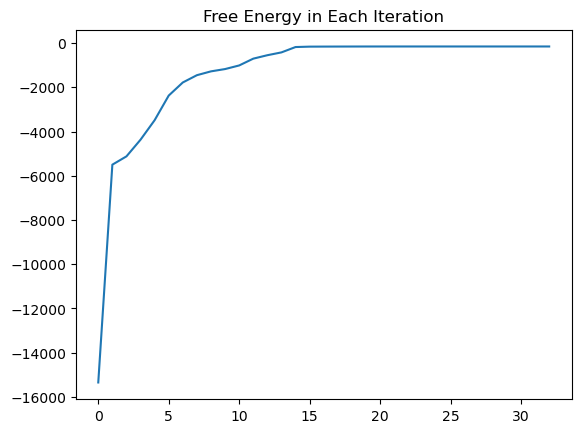

In [6]:
np.random.seed(1994)
K = 8
mu, sigma, pie, Fs = LearnBinFactors(Y, K, 200)
plt.plot(Fs)
plt.title("Free Energy in Each Iteration")

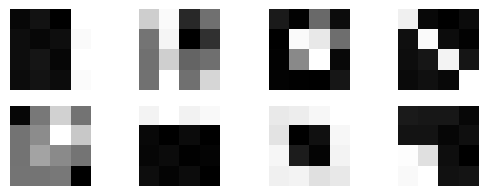

In [7]:
for k in range(K):
    plt.subplot(4, 4, k + 1)
    plt.imshow(np.reshape(mu.T[k], (4, 4)), cmap=plt.gray(), interpolation='none')
    plt.axis('off')

plt.show()

[-40.957714574934606, -16.300941297761526, -16.20017499850291, -16.135756331928732, -16.106795318990066, -16.10260123171158, -16.102253368028556, -16.102215956063056, -16.10221044478277, -16.102209517677423, -16.10220935520322, -16.102209326411682, -16.102209321295675, -16.102209320386088, -16.10220932022436, -16.102209320195605, -16.10220932019049, -16.10220932018958, -16.102209320189424, -16.102209320189395, -16.102209320189388]
[-24.039279764429505, -19.37447038138711, -19.084108799518205, -19.046971091183643, -19.042247516700513, -19.04157361320467, -19.04147721725869, -19.041466686811688, -19.041465804543805, -19.04146572631064, -19.04146571463482, -19.041465712575256, -19.041465712283976, -19.041465712253327, -19.041465712250805, -19.04146571225058, -19.041465712250545, -19.04146571225054, -19.04146571225054, -19.04146571225054, -19.04146571225054]
[-40.82747365954656, -40.798735489539716, -40.79859320953478, -40.79859311023024, -40.798593110222555, -40.79859311022255, -40.798593

/tmp/ipykernel_2300722/2676369440.py:23: RuntimeWarning: divide by zero encountered in log
  log_diff_Fs_1 = np.log(np.array(this_Fs[1:]) - np.array(this_Fs[:-1]))


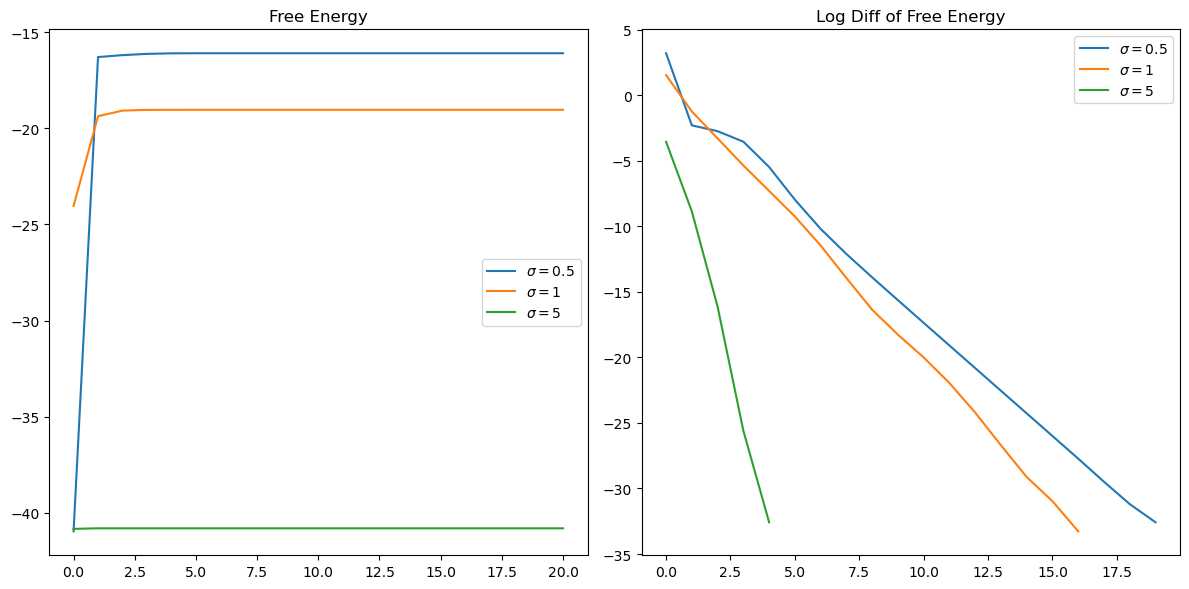

In [8]:
Y1 = Y[0,:]
K1 = 4

Fs_sigma = []
sigmas = [0.5, 1, 5]
pie_init = np.empty(K1); pie_init.fill(0.5)
mu_init = np.random.randint(0, 2, (D, K1))
lmbda_init = np.tile(pie_init, (1, 1))
for this_sigma in sigmas:
    lmbda, M_Fs = MeanField(Y1[None, :], mu_init, this_sigma, pie_init, lmbda_init, 20, 0)
    Fs_sigma.append(M_Fs)

color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=False)
for idx, this_Fs in enumerate(Fs_sigma):
    # Use the same color for both subplots
    color = color_cycle[idx]
    print(this_Fs)
    # Plot on first subplot
    axes[0].plot(this_Fs, label=rf'$\sigma = {sigmas[idx]}$', color=color)
    
    # Compute and plot on second subplot
    log_diff_Fs_1 = np.log(np.array(this_Fs[1:]) - np.array(this_Fs[:-1]))
    axes[1].plot(log_diff_Fs_1, label=rf'$\sigma = {sigmas[idx]}$', color=color)
# Add titles and legends
axes[0].set_title('Free Energy')
axes[0].legend()
axes[1].set_title('Log Diff of Free Energy')
axes[1].legend()

plt.tight_layout()
plt.show()

# Q4

In [ ]:
import scipy.special


class VB_Mean_Field_simple:
    """
    Variational Bayesian Hyperparameter optimisation algorithm to automatically
    determine K, the number of hidden binary variables
    """
    def __init__(self, data, K, alpha, pi_alpha, pi_beta, sigma_alpha, sigma_beta):
        """
        data: (N, D) np array, data
        K : Number of hidden binary variables
        alpha: (K,) prior precision of column Lambda
        pi_alpha, pi_beta: prior of pi ~ Beta(pi_alpha, pi_beta)
        sigma_alpha, sigma_beta: prior of sigma^2 ~ InvGamma(sigma_alpha, sigma_beta)
        """
        self.X = data.copy()
        self.N, self.D = data.shape
        self.K = K
        self.alpha = alpha.copy()
        self.pi_alpha = pi_alpha
        self.pi_beta = pi_beta
        self.sigma_alpha = sigma_alpha
        self.sigma_beta = sigma_beta
        self.reset()

    def reset(self):
        # alpha_opt is the optimised alpha based on ARD
        self.alpha_opt = self.alpha.copy()

        # lmbda is the q_s in each iteration, (N, K)
        self.lmbda = np.empty((self.N, self.K))
        self.lmbda.fill(0.5)

        # mu_lambda:         (D, K) np array, mean of q_Lambda
        self.mu_lambda = np.array(np.random.randint(0, 2, (self.D, self.K)), dtype=np.float64)

        # tr_var_lambda:     (K, ) np array, trace of V_i of q_Lambda
        self.tr_var_lambda = self.D / self.alpha

        # q_pi_alpha:        (K, ) np array, alpha for q_pi
        self.q_pi_alpha = np.empty(self.K)
        self.q_pi_alpha.fill(self.pi_alpha)

        # q_pi_beta:         (K, ) np array, beta for q_pi
        self.q_pi_beta = np.empty(self.K)
        self.q_pi_beta.fill(self.pi_beta)

        # q_sigma_alpha:     scalar, alpha for q_sigma
        self.q_sigma_alpha = self.sigma_alpha

        # q_sigma_beta:      scalar, beta for q_sigma
        self.q_sigma_beta = self.sigma_beta

        self.Free_energy = 0.0


    def E_step(self, maxsteps, tol):
        """
        E step for VB

        Output:
        Fs:          Free energy in each iteration
        """
        
        m2 = self.mu_lambda.T @ self.mu_lambda # (K, K)
        m2_diag = np.diag(m2) # (K, )
        m2_offdiag = m2 - np.diag(m2_diag)
        m_x = self.X @ self.mu_lambda # (N, K)
        digamma_alpha_beta = scipy.special.digamma(self.q_pi_alpha) - scipy.special.digamma(self.q_pi_beta) # (K, )
        partial_logit = self.q_sigma_alpha / self.q_sigma_beta * m_x + digamma_alpha_beta[None, :] - self.q_sigma_alpha / self.q_sigma_beta / 2.0 * (m2_diag[None, :] + self.tr_var_lambda[None, :]) # (N, K)

        lmbda_mu_cross = np.array([lmbda_row @ m2_offdiag @ lmbda_row.T for lmbda_row in self.lmbda])

        F_n = (
            np.sum(self.lmbda * digamma_alpha_beta, axis=1)  # Prior term
            - np.sum(self.lmbda * np.log(self.lmbda) + (1 - self.lmbda) * np.log(1 - self.lmbda), axis=1)  # Entropy term
            - 0.5 * self.q_sigma_alpha / self.q_sigma_beta * (-2 * np.sum(self.lmbda * m_x, axis=1) + lmbda_mu_cross.flatten() + np.sum(self.lmbda * (m2_diag[None, :] + self.tr_var_lambda[None, :]), axis=1))  # Likelihood term without ||x||^2
        )
        F = np.sum(F_n)
        Fs = [F]

        for _ in range(maxsteps):
            old_F = F
            for k in range(self.K):
                lmbda_mu_without_k = self.lmbda @ m2_offdiag[:, k] # (N, )
                logit_1 = partial_logit[:, k] - self.q_sigma_alpha / self.q_sigma_beta * lmbda_mu_without_k
                self.lmbda[:, k] = np.clip(1.0 / (1.0 + np.exp(-logit_1)), 1e-8, 1 - 1e-8)

            lmbda_mu_cross = np.array([lmbda_row @ m2_offdiag @ lmbda_row.T for lmbda_row in self.lmbda])
            
            F_n = (
                np.sum(self.lmbda * digamma_alpha_beta, axis=1)  # Prior term
                - np.sum(self.lmbda * np.log(self.lmbda) + (1 - self.lmbda) * np.log(1 - self.lmbda), axis=1)  # Entropy term
                - 0.5 * self.q_sigma_alpha / self.q_sigma_beta * (-2 * np.sum(self.lmbda * m_x, axis=1) + lmbda_mu_cross.flatten() + np.sum(self.lmbda * (m2_diag[None, :] + self.tr_var_lambda[None, :]), axis=1))  # Likelihood term without ||x||^2
            )

            F = np.sum(F_n)
            Fs.append(F)
            if np.abs(F - old_F) < tol:
                break
        return Fs
    

    def M_step(self):
        """
        M for VB
        """
        # Update \Lambda
        precisions = self.q_sigma_alpha / self.q_sigma_beta * np.sum(self.lmbda, axis=0) + self.alpha_opt
        self.tr_var_lambda = 1.0 / precisions
        sum_x_lambda = []
        for this_X, this_lmbda in zip(self.X, self.lmbda):
            tmp_x_lambda = this_X[:, None] * this_lmbda[None, :]
            sum_x_lambda.append(tmp_x_lambda)
        sum_x_lambda = np.sum(np.array(sum_x_lambda), axis=0)
        self.mu_lambda = self.q_sigma_alpha / self.q_sigma_beta * sum_x_lambda * (1.0 / precisions)[None, :]
        
        # Optimise \alpha
        m2 = self.mu_lambda.T @ self.mu_lambda # (K, K)
        m2_diag = np.diag(m2) # (K, )
        m2_offdiag = m2 - np.diag(m2_diag)
        m_x = self.X @ self.mu_lambda # (N, K)
        lmbda_mu_cross = np.array([lmbda_row @ m2_offdiag @ lmbda_row.T for lmbda_row in self.lmbda])
        self.alpha_opt = self.D / (m2_diag + self.tr_var_lambda + 1.0e-6)

        # Update \pi
        self.q_pi_alpha = self.pi_alpha + np.sum(self.lmbda, axis=0)
        self.q_pi_beta = self.pi_beta + self.N - np.sum(self.lmbda, axis=0)

        # Update \sigma^2
        x2 = self.X @ self.X.T # (N, N)
        x2_diag = np.diag(x2)
        self.q_sigma_alpha = self.sigma_alpha + (self.N * self.D) / 2.0
        self.q_sigma_beta = self.sigma_beta + 0.5 * np.sum(x2_diag -2 * np.sum(self.lmbda * m_x, axis=1) + lmbda_mu_cross.flatten() + np.sum(self.lmbda * (m2_diag[None, :] + self.tr_var_lambda[None, :]), axis=1))

        digamma_alpha = scipy.special.digamma(self.q_pi_alpha)
        digamma_beta = scipy.special.digamma(self.q_pi_beta)
        digamma_both = scipy.special.digamma(self.q_pi_alpha + self.q_pi_beta)
        digamma_sigma_alpha = scipy.special.digamma(self.q_sigma_alpha)
        self.Free_energy = (
            -self.N * self.D / 2 * (np.log(self.q_sigma_beta) - digamma_sigma_alpha)
            + 0.5 * np.sum(self.D * np.log(self.alpha_opt) - self.alpha_opt * (m2_diag + self.tr_var_lambda))
            + (self.pi_alpha - 1) * np.sum(digamma_alpha - digamma_both) + (self.pi_beta - 1) * np.sum(digamma_beta - digamma_both)
            - (self.sigma_alpha + 1) * (np.log(self.q_sigma_beta) - digamma_sigma_alpha) - self.q_sigma_alpha * self.sigma_beta / self.q_sigma_beta
            + 0.5 * np.sum(self.D * np.log(self.tr_var_lambda))
            + np.sum(scipy.special.betaln(self.q_pi_alpha, self.q_pi_beta) - (self.q_pi_alpha - 1) * digamma_alpha - (self.q_pi_beta - 1) * digamma_beta + (self.q_pi_alpha + self.q_pi_beta - 2) * digamma_both)
            + self.q_sigma_alpha + np.log(self.q_sigma_beta) + scipy.special.gammaln(self.q_sigma_alpha) - (1 + self.q_sigma_alpha) * digamma_sigma_alpha
            + np.sum(self.lmbda * (digamma_alpha - digamma_both))
            - np.sum(self.lmbda * np.log(self.lmbda) + (1 - self.lmbda) * np.log(1 - self.lmbda))
            - 0.5 * self.q_sigma_alpha / self.q_sigma_beta * np.sum(x2_diag -2 * np.sum(self.lmbda * m_x, axis=1) + lmbda_mu_cross.flatten() + np.sum(self.lmbda * (m2_diag[None, :] + self.tr_var_lambda[None, :]), axis=1))
        )

    def run(self, max_iter, max_E_iter, E_tol):
        self.reset()
        Fs_E = []
        Fs_all = []
        for _ in range(max_iter):
            this_Fs = self.E_step(max_E_iter, E_tol)
            Fs_E.append(this_Fs[-1])
            self.M_step()
            Fs_all.append(self.Free_energy)
        return Fs_E, Fs_all


In [386]:
class VB_Mean_Field:
    """
    Variational Bayesian Hyperparameter optimisation algorithm to automatically
    determine K, the number of hidden binary variables
    """
    def __init__(self, data, K, alpha, pi_alpha, pi_beta, sigma_alpha, sigma_beta):
        """
        data: (N, D) np array, data
        K : Number of hidden binary variables
        alpha: (K,) prior precision of column Lambda
        pi_alpha, pi_beta: prior of pi ~ Beta(pi_alpha, pi_beta)
        sigma_alpha, sigma_beta: prior of sigma^2 ~ InvGamma(sigma_alpha, sigma_beta)
        """
        self.X = data.copy()
        self.N, self.D = data.shape
        self.K = K
        self.alpha = alpha.copy()
        self.pi_alpha = pi_alpha
        self.pi_beta = pi_beta
        self.sigma_alpha = sigma_alpha
        self.sigma_beta = sigma_beta
        self.reset()

    def reset(self):
        np.random.seed(123)
        # alpha_opt is the optimised alpha based on ARD
        self.alpha_opt = self.alpha.copy()

        # lmbda is the q_s in each iteration, (N, K)
        self.lmbda = np.random.rand(self.N, self.K)
        # self.lmbda = np.empty((self.N, self.K))
        # self.lmbda.fill(0.5)

        # mu_lambda:         (D, K) np array, mean of q_Lambda
        self.mu_lambda = np.random.rand(self.D, self.K)#np.array(np.random.randint(0, 2, (self.D, self.K)), dtype=np.float64)

        # tr_var_lambda:     (K, ) np array, trace of V_i of q_Lambda
        self.tr_var_lambda = self.D / self.alpha

        # q_pi_alpha:        (K, ) np array, alpha for q_pi
        self.q_pi_alpha = np.empty(self.K)
        self.q_pi_alpha.fill(self.pi_alpha)

        # q_pi_beta:         (K, ) np array, beta for q_pi
        self.q_pi_beta = np.empty(self.K)
        self.q_pi_beta.fill(self.pi_beta)

        # q_sigma_alpha:     scalar, alpha for q_sigma
        self.q_sigma_alpha = self.sigma_alpha

        # q_sigma_beta:      scalar, beta for q_sigma
        self.q_sigma_beta = self.sigma_beta

        self.Free_energy = 0.0


    def E_step(self, maxsteps, tol):
        """
        E step for VB

        Output:
        Fs:          Free energy in each iteration
        """
        
        m2 = self.mu_lambda.T @ self.mu_lambda # (K, K)
        m2_diag = np.diag(m2) # (K, )
        m2_offdiag = m2 - np.diag(m2_diag)
        m_x = self.X @ self.mu_lambda # (N, K)
        digamma_alpha_beta = scipy.special.digamma(self.q_pi_alpha) - scipy.special.digamma(self.q_pi_beta) # (K, )
        partial_logit = self.q_sigma_alpha / self.q_sigma_beta * m_x + digamma_alpha_beta[None, :] - self.q_sigma_alpha / self.q_sigma_beta / 2.0 * (m2_diag[None, :] + self.tr_var_lambda[None, :]) # (N, K)

        lmbda_mu_cross = np.array([lmbda_row @ m2_offdiag @ lmbda_row.T for lmbda_row in self.lmbda])

        F_n = (
            np.sum(self.lmbda * digamma_alpha_beta, axis=1)  # Prior term
            - np.sum(self.lmbda * np.log(self.lmbda) + (1 - self.lmbda) * np.log(1 - self.lmbda), axis=1)  # Entropy term
            - 0.5 * self.q_sigma_alpha / self.q_sigma_beta * (-2 * np.sum(self.lmbda * m_x, axis=1) + lmbda_mu_cross.flatten() + np.sum(self.lmbda * (m2_diag[None, :] + self.tr_var_lambda[None, :]), axis=1))  # Likelihood term without ||x||^2
        )
        F = np.sum(F_n)
        Fs = [F]

        for _ in range(maxsteps):
            old_F = F
            for k in range(self.K):
                lmbda_mu_without_k = self.lmbda @ m2_offdiag[:, k] # (N, )
                logit_1 = partial_logit[:, k] - self.q_sigma_alpha / self.q_sigma_beta * lmbda_mu_without_k
                self.lmbda[:, k] = np.clip(1.0 / (1.0 + np.exp(-logit_1)), 1e-8, 1 - 1e-8)

            lmbda_mu_cross = np.array([lmbda_row @ m2_offdiag @ lmbda_row.T for lmbda_row in self.lmbda])
            
            F_n = (
                np.sum(self.lmbda * digamma_alpha_beta, axis=1)  # Prior term
                - np.sum(self.lmbda * np.log(self.lmbda) + (1 - self.lmbda) * np.log(1 - self.lmbda), axis=1)  # Entropy term
                - 0.5 * self.q_sigma_alpha / self.q_sigma_beta * (-2 * np.sum(self.lmbda * m_x, axis=1) + lmbda_mu_cross.flatten() + np.sum(self.lmbda * (m2_diag[None, :] + self.tr_var_lambda[None, :]), axis=1))  # Likelihood term without ||x||^2
            )

            F = np.sum(F_n)
            Fs.append(F)
            if np.abs(F - old_F) < tol:
                break
        return Fs
    

    def M_step(self):
        """
        M for VB
        """
        # Update \Lambda
        precisions = self.q_sigma_alpha / self.q_sigma_beta * np.sum(self.lmbda, axis=0) + self.alpha_opt
        self.tr_var_lambda = 1.0 / precisions
        sum_x_lambda = []
        for this_X, this_lmbda in zip(self.X, self.lmbda):
            tmp_x_lambda = this_X[:, None] * this_lmbda[None, :]
            sum_x_lambda.append(tmp_x_lambda)
        sum_x_lambda = np.sum(np.array(sum_x_lambda), axis=0)

        # iterate multiple times to update mu_lambda
        for _ in range(10):
            for i in range(self.K):
                cross_terms = self.lmbda @ self.mu_lambda.T - self.lmbda[:, i].reshape(-1,1) @ self.mu_lambda[:, i].reshape(1,-1) # (N, D)
                cross_terms = np.sum(cross_terms * self.lmbda[:, i][:, None], axis=0) # (D, )
                self.mu_lambda[:, i] = self.q_sigma_alpha / self.q_sigma_beta * (sum_x_lambda[:, i] - cross_terms) * (1.0 / precisions[i])
        
        # Optimise \alpha
        m2 = self.mu_lambda.T @ self.mu_lambda # (K, K)
        m2_diag = np.diag(m2) # (K, )
        m2_offdiag = m2 - np.diag(m2_diag)
        m_x = self.X @ self.mu_lambda # (N, K)
        lmbda_mu_cross = np.array([lmbda_row @ m2_offdiag @ lmbda_row.T for lmbda_row in self.lmbda])
        self.alpha_opt = self.D / (m2_diag + self.tr_var_lambda + 1.0e-6)

        # Update \pi
        self.q_pi_alpha = self.pi_alpha + np.sum(self.lmbda, axis=0)
        self.q_pi_beta = self.pi_beta + self.N - np.sum(self.lmbda, axis=0)

        # Update \sigma^2
        x2 = self.X @ self.X.T # (N, N)
        x2_diag = np.diag(x2)
        self.q_sigma_alpha = self.sigma_alpha + (self.N * self.D) / 2.0
        self.q_sigma_beta = self.sigma_beta + 0.5 * np.sum(x2_diag -2 * np.sum(self.lmbda * m_x, axis=1) + lmbda_mu_cross.flatten() + np.sum(self.lmbda * (m2_diag[None, :] + self.tr_var_lambda[None, :]), axis=1))

        digamma_alpha = scipy.special.digamma(self.q_pi_alpha)
        digamma_beta = scipy.special.digamma(self.q_pi_beta)
        digamma_both = scipy.special.digamma(self.q_pi_alpha + self.q_pi_beta)
        digamma_sigma_alpha = scipy.special.digamma(self.q_sigma_alpha)
        self.Free_energy = (
            -self.N * self.D / 2 * (np.log(self.q_sigma_beta) - digamma_sigma_alpha)
            + 0.5 * np.sum(self.D * np.log(self.alpha_opt) - self.alpha_opt * (m2_diag + self.tr_var_lambda))
            + (self.pi_alpha - 1) * np.sum(digamma_alpha - digamma_both) + (self.pi_beta - 1) * np.sum(digamma_beta - digamma_both)
            - (self.sigma_alpha + 1) * (np.log(self.q_sigma_beta) - digamma_sigma_alpha) - self.q_sigma_alpha * self.sigma_beta / self.q_sigma_beta
            + 0.5 * np.sum(self.D * np.log(self.tr_var_lambda))
            + np.sum(scipy.special.betaln(self.q_pi_alpha, self.q_pi_beta) - (self.q_pi_alpha - 1) * digamma_alpha - (self.q_pi_beta - 1) * digamma_beta + (self.q_pi_alpha + self.q_pi_beta - 2) * digamma_both)
            + self.q_sigma_alpha + np.log(self.q_sigma_beta) + scipy.special.gammaln(self.q_sigma_alpha) - (1 + self.q_sigma_alpha) * digamma_sigma_alpha
            + np.sum(self.lmbda * (digamma_alpha - digamma_both))
            - np.sum(self.lmbda * np.log(self.lmbda) + (1 - self.lmbda) * np.log(1 - self.lmbda))
            - 0.5 * self.q_sigma_alpha / self.q_sigma_beta * np.sum(x2_diag -2 * np.sum(self.lmbda * m_x, axis=1) + lmbda_mu_cross.flatten() + np.sum(self.lmbda * (m2_diag[None, :] + self.tr_var_lambda[None, :]), axis=1))
        )

    def run(self, max_iter, max_E_iter, E_tol, tol):
        self.reset()
        Fs_E = []
        Fs_all = []
        for _ in range(max_iter):
            this_Fs = self.E_step(max_E_iter, E_tol)
            Fs_E.append(this_Fs[-1])
            self.M_step()
            Fs_all.append(self.Free_energy)
            if len(Fs_all) > 1 and np.abs(Fs_all[-1] / Fs_all[-2] - 1) < tol:
                break
        return Fs_E, Fs_all

In [407]:
K = 16
alpha0 = np.ones(K) * 2
pi_alpha0 = 1.0
pi_beta0 = 1.0
sigma_alpha0 = 1.01
sigma_beta0 = 1


In [274]:
# do grid search for all prior parameters
F_collection = []
alpha0_collection = [0.01, 0.1, 1, 2, 5, 10]
pi_alpha0_collection = [10.0]
pi_beta0_collection = [5.0]
sigma_alpha0_collection = [7.0]
sigma_beta0_collection = [10.0]
for alpha0 in alpha0_collection:
    for pi_alpha0 in pi_alpha0_collection:
        for pi_beta0 in pi_beta0_collection:
            for sigma_alpha0 in sigma_alpha0_collection:
                for sigma_beta0 in sigma_beta0_collection:
                    this_VB = VB_Mean_Field(Y, K, alpha0 * np.ones(K), pi_alpha0, pi_beta0, sigma_alpha0, sigma_beta0)
                    this_F_E, this_F_all = this_VB.run(1000, 100, 1.0e-8, 1.0e-8)
                    F_collection.append(this_F_all[-1])
                    print(f"alpha0={alpha0}, pi_alpha0={pi_alpha0}, pi_beta0={pi_beta0}, sigma_alpha0={sigma_alpha0}, sigma_beta0={sigma_beta0}, Free Energy={this_F_all[-1]}")
max_free_energy = np.max(F_collection)
max_idx = np.argmax(F_collection)
max_parameters = (
    alpha0_collection[max_idx // (len(pi_alpha0_collection) * len(pi_beta0_collection) * len(sigma_alpha0_collection) * len(sigma_beta0_collection))],
    pi_alpha0_collection[(max_idx // (len(pi_beta0_collection) * len(sigma_alpha0_collection) * len(sigma_beta0_collection))) % len(pi_alpha0_collection)],
    pi_beta0_collection[(max_idx // (len(sigma_alpha0_collection) * len(sigma_beta0_collection))) % len(pi_beta0_collection)],
    sigma_alpha0_collection[(max_idx // len(sigma_beta0_collection)) % len(sigma_alpha0_collection)],
    sigma_beta0_collection[max_idx % len(sigma_beta0_collection)]
)

alpha0=0.01, pi_alpha0=10.0, pi_beta0=5.0, sigma_alpha0=7.0, sigma_beta0=10.0, Free Energy=3385.728607913792
alpha0=0.1, pi_alpha0=10.0, pi_beta0=5.0, sigma_alpha0=7.0, sigma_beta0=10.0, Free Energy=2741.3926164502373
alpha0=1, pi_alpha0=10.0, pi_beta0=5.0, sigma_alpha0=7.0, sigma_beta0=10.0, Free Energy=1461.1583928122245
alpha0=2, pi_alpha0=10.0, pi_beta0=5.0, sigma_alpha0=7.0, sigma_beta0=10.0, Free Energy=2239.938867543936
alpha0=5, pi_alpha0=10.0, pi_beta0=5.0, sigma_alpha0=7.0, sigma_beta0=10.0, Free Energy=2857.524837712862
alpha0=10, pi_alpha0=10.0, pi_beta0=5.0, sigma_alpha0=7.0, sigma_beta0=10.0, Free Energy=2611.4006217238343


In [415]:
EM_VB = VB_Mean_Field(Y, K, alpha0, pi_alpha0, pi_beta0, sigma_alpha0, sigma_beta0)

In [416]:
F_E, F_all = EM_VB.run(200, 100, 1.0e-8, 1.0e-8)

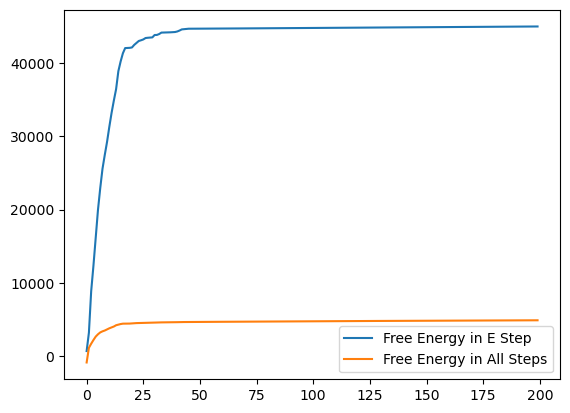

In [417]:
plt.figure()
plt.plot(F_E, label='Free Energy in E Step')
plt.plot(F_all, label='Free Energy in All Steps')
plt.legend()
plt.show()

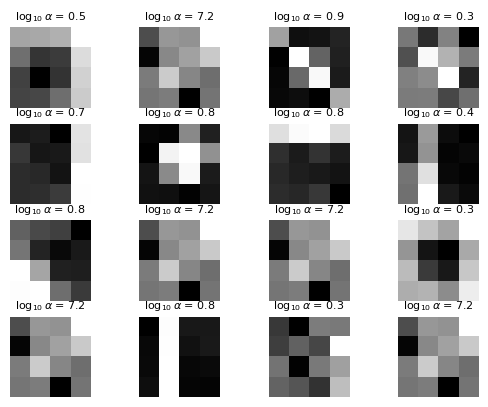

In [418]:
for i, k in enumerate(range(K)):
    plt.subplot(4, 4, k + 1)
    plt.imshow(np.reshape(EM_VB.mu_lambda.T[k], (4, 4)), cmap=plt.gray(), interpolation='none')
    plt.axis('off')
    plt.title(r'$\log_{{10}}\alpha$ = {:.1f}'.format(np.log10(EM_VB.alpha_opt[i])),fontsize=8)

plt.show()

In [425]:
Ks = np.arange(4, 17, 2)
F_collection = []
effective_alphas = []
for this_K in Ks:
    alpha0 = np.ones(this_K) * 2
    EM_VB = VB_Mean_Field(Y, this_K, alpha0, pi_alpha0, pi_beta0, sigma_alpha0, sigma_beta0)
    F_E, F_all = EM_VB.run(500, 100, 1.0e-8, 1.0e-8)
    F_collection.append(F_all)
    this_alpha_opt = EM_VB.alpha_opt
    effective_alphas.append(np.sum(np.log10(this_alpha_opt) < 1))

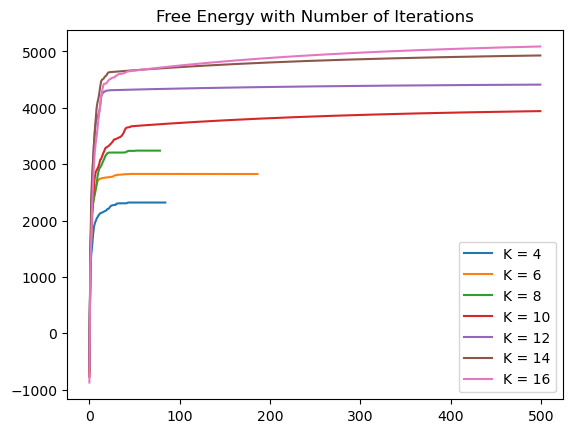

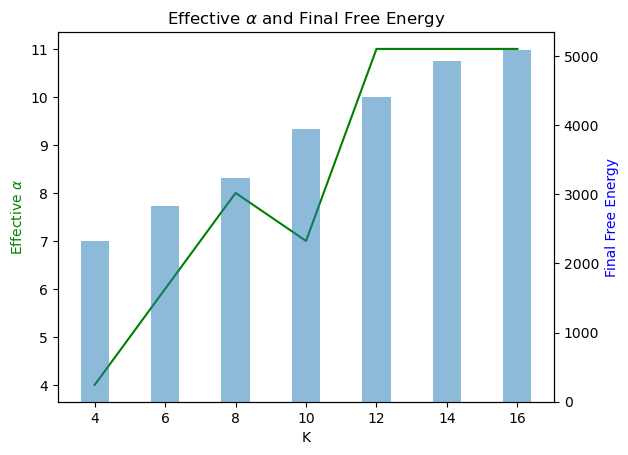

In [427]:
plt.figure()
for idx, this_F in enumerate(F_collection):
    plt.plot(this_F, label=f'K = {Ks[idx]}')
plt.legend()
plt.title('Free Energy with Number of Iterations')
plt.show()

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(Ks, effective_alphas, 'g-')
ax2.bar(Ks, [this_F[-1] for this_F in F_collection], alpha=0.5)
ax1.set_xlabel('K')
ax1.set_ylabel(r'Effective $\alpha$', color='g')
ax2.set_ylabel('Final Free Energy', color='b')
plt.title(r'Effective $\alpha$ and Final Free Energy')
plt.show()

# Q6

In [162]:
class LoopyBP_EM:

    def __init__(self, data, K, random_seed=1994):
        """
        data: (N, D) np array, data
        K : Number of hidden binary variables
        """
        np.random.seed(random_seed)
        self.X = data.copy()
        self.K = K
        self.N, self.D = data.shape
        self.a = np.zeros((self.N, self.K))
        self.b = np.random.rand(self.N, self.K, self.K)
        # fill self.b with 0 on the diagonal
        for n in range(self.N):
            np.fill_diagonal(self.b[n], 0.0)
        self.lmbda = np.random.rand(self.N, self.K)
        # We run M step before the full EM algorithm
        # These will be initialised in M step
        self.sigma = None
        self.mu = None
        self.pie = None


    def LoopyBP(self, maxsteps, tol, damping=0.5):
        """
        E step doing loopy BP

        Input:
        mu:         (D, K) np array, means
        sigma:      scalar, variance of data
        pie:        (K,) np array, prior on s
        maxsteps:   max iteration
        tol:        tolerance of halting the iteration
        damping:    damping factor for updating b

        Output:
        Fs:         Free energy in each iteration
        """
        K = self.K
        mu2 = self.mu.T @ self.mu # (K, K)
        mu2_diag = np.diag(mu2)
        mu2_offdiag = mu2 - np.diag(mu2_diag)
        mu_x = self.X @ self.mu # (N, K)
        log_pi = np.log(self.pie.flatten()) # (K, )
        log_one_minus_pi = np.log(1 - self.pie.flatten()) # (K, )
        log_pi_one_minus_pi = log_pi - log_one_minus_pi # (K, )
        lmbda_mu_cross = np.array([lmbda_row @ mu2_offdiag @ lmbda_row.T for lmbda_row in self.lmbda])
        F_n = (
            np.sum(self.lmbda * log_pi_one_minus_pi, axis=1) + np.sum(log_one_minus_pi)  # Prior term
            - np.sum(self.lmbda * np.log(self.lmbda) + (1 - self.lmbda) * np.log(1 - self.lmbda), axis=1)  # Entropy term
            - 0.5 / self.sigma**2 * (np.sum(self.X**2, axis=1) -2 * np.sum(self.lmbda * mu_x, axis=1) + lmbda_mu_cross.flatten() + np.sum(self.lmbda * mu2_diag[None,:], axis=1))  # Likelihood term
            - self.D / 2 * np.log(2 * np.pi * self.sigma**2)  # Normalisation term
        )
        F = np.sum(F_n)
        Fs = [F]
        self.a = mu_x / self.sigma**2 - 0.5 * mu2_diag[None, :] / self.sigma**2 + log_pi_one_minus_pi[None, :]
        old_b = self.b.copy()
        old_lambda = self.lmbda.copy()
        increasing_idx = 0
        max_F = F
        for _ in range(maxsteps):
            b_new = self.b.copy()
            for j in range(K):
                for i in range(j + 1, K):
                    # Update b_{j -> i} using theta_j
                    theta_j = self.a[:, j] + np.sum(self.b[:, :, j], axis=1) - self.b[:, j, j] - self.b[:, i, j]
                    numerator_j = np.exp(-mu2[i, j] / self.sigma**2 + theta_j) + 1
                    denominator_j = np.exp(theta_j) + 1
                    b_update_j = np.log(numerator_j / denominator_j)
                    
                    # Update b_{i -> j} using theta_i
                    theta_i = self.a[:, i] + np.sum(self.b[:, :, i], axis=1) - self.b[:, i, i] - self.b[:, j, i]
                    numerator_i = np.exp(-mu2[i, j] / self.sigma**2 + theta_i) + 1
                    denominator_i = np.exp(theta_i) + 1
                    b_update_i = np.log(numerator_i / denominator_i)
                    
                    # Apply damping
                    b_new[:, j, i] = damping * b_update_j + (1 - damping) * self.b[:, j, i]
                    b_new[:, i, j] = damping * b_update_i + (1 - damping) * self.b[:, i, j]
            diff = np.max(np.abs(self.b - b_new))
            self.b = b_new
            logit_1 = self.a + np.sum(self.b, axis=1) - np.diagonal(self.b, axis1=1, axis2=2)
            self.lmbda = np.clip(1.0 / (1.0 + np.exp(-logit_1)), 1e-8, 1 - 1e-8)

            lmbda_mu_cross = np.array([lmbda_row @ mu2_offdiag @ lmbda_row.T for lmbda_row in self.lmbda])
            
            F_n = (
                np.sum(self.lmbda * log_pi_one_minus_pi, axis=1) + np.sum(log_one_minus_pi)  # Prior term
                - np.sum(self.lmbda * np.log(self.lmbda) + (1 - self.lmbda) * np.log(1 - self.lmbda), axis=1)  # Entropy term
                - 0.5 / self.sigma**2 * (np.sum(self.X**2, axis=1) -2 * np.sum(self.lmbda * mu_x, axis=1) + lmbda_mu_cross.flatten() + np.sum(self.lmbda * mu2_diag[None,:], axis=1))  # Likelihood term 
                - self.D / 2 * np.log(2 * np.pi * self.sigma**2)  # Normalisation term
            )

            F = np.sum(F_n)
            Fs.append(F)
            if F > max_F:
                max_F = F
                old_b = self.b.copy()
                old_lambda = self.lmbda.copy()
                increasing_idx = _ + 1
            if diff < tol:
                break
        if Fs[-1] < Fs[0] and diff >= tol:
            self.b = old_b
            self.lmbda = old_lambda
            Fs = Fs[:increasing_idx + 1]
        return Fs
    
    def m_step(self):
        """
        We calculate the M step of the EM algorithm:
        -----------------
            ES: shape (N, K) E_q[s]
            ESS: shape (K, K) sum over data points of E_q[ss'] (N, K, K)
                            if E_q[ss'] is provided, the sum over N is done for you.

        Update these parameters:
        --------
            mu: shape (D, K) matrix of means in p(y|{s_i},mu,sigma)
            sigma: shape (,)    standard deviation in same
            pie: shape (1, K) vector of parameters specifying generative distribution for s

        Output:
        --------
            F: scalar, the free energy
        """
        N = self.N
        ES = self.lmbda
        ESS = np.array([this_lmbda.reshape(-1, 1) * this_lmbda.reshape(1, -1) for this_lmbda in self.lmbda])
        for n in range(N):
            np.fill_diagonal(ESS[n, :, :], self.lmbda[n])
        K = self.K
        ESS = np.sum(ESS, axis=0)
        if ESS.shape != (K, K):
            raise TypeError('ESS must be square and have the same number of columns as ES')

        self.mu = np.dot(np.dot(np.linalg.inv(ESS), ES.T), self.X).T
        self.sigma = np.sqrt((np.trace(np.dot(self.X.T, self.X)) + np.trace(np.dot(np.dot(self.mu.T, self.mu), ESS))
                        - 2 * np.trace(np.dot(np.dot(ES.T, self.X), self.mu))) / (N * D))
        self.pie = np.mean(ES, axis=0, keepdims=True)
        self.pie = np.clip(self.pie, 1e-8, 1 - 1e-8)

        mu2 = self.mu.T @ self.mu # (K, K)
        mu2_diag = np.diag(mu2)
        mu2_offdiag = mu2 - np.diag(mu2_diag)
        mu_x = self.X @ self.mu # (N, K)
        log_pi = np.log(self.pie.flatten()) # (K, )
        log_one_minus_pi = np.log(1 - self.pie.flatten()) # (K, )
        log_pi_one_minus_pi = log_pi - log_one_minus_pi # (K, )
        lmbda_mu_cross = np.array([lmbda_row @ mu2_offdiag @ lmbda_row.T for lmbda_row in self.lmbda])
        F_n = (
                np.sum(self.lmbda * log_pi_one_minus_pi, axis=1) + np.sum(log_one_minus_pi)  # Prior term
                - np.sum(self.lmbda * np.log(self.lmbda) + (1 - self.lmbda) * np.log(1 - self.lmbda), axis=1)  # Entropy term
                - 0.5 / self.sigma**2 * (np.sum(self.X**2, axis=1) -2 * np.sum(self.lmbda * mu_x, axis=1) + lmbda_mu_cross.flatten() + np.sum(self.lmbda * mu2_diag[None,:], axis=1))  # Likelihood term 
                - self.D / 2 * np.log(2 * np.pi * self.sigma**2)  # Normalisation term
            )

        F = np.sum(F_n)
        return F
    
    def run(self, max_iter, max_E_iter, tol, damping=0.5):
        E_Fs = []
        M_Fs = []
        # run M step once to initialise mu, pie and sigma
        self.m_step()
        for _ in range(max_iter):
            # E step
            E_F = self.LoopyBP(max_E_iter, 1.0e-8, damping)
            E_Fs.append(E_F[-1])
            # M step
            M_F = self.m_step()
            M_Fs.append(M_F)
            # check convergence
            if len(M_Fs) > 1 and np.abs(M_Fs[-1] - M_Fs[-2]) < tol:
                break
        return E_Fs, M_Fs

In [166]:
K = 8
random_seeds = [123, 234, 672, 2987, 9271, 18888, 20000, 439, 219, 1994, 2000, 2025]
E_Fs = []
M_Fs = []
for i, rs in enumerate(random_seeds):
    loopyEP = LoopyBP_EM(Y, K, rs)
    this_E_Fs, this_M_Fs = loopyEP.run(100, 50, 1.0e-8, 0.5)
    E_Fs.append(this_E_Fs[-1])
    M_Fs.append(this_M_Fs[-1])
i_max = np.argmax(M_Fs)
loopyEP = LoopyBP_EM(Y, K, random_seeds[i_max])
E_Fs, M_Fs = loopyEP.run(100, 50, 1.0e-8, 0.5)

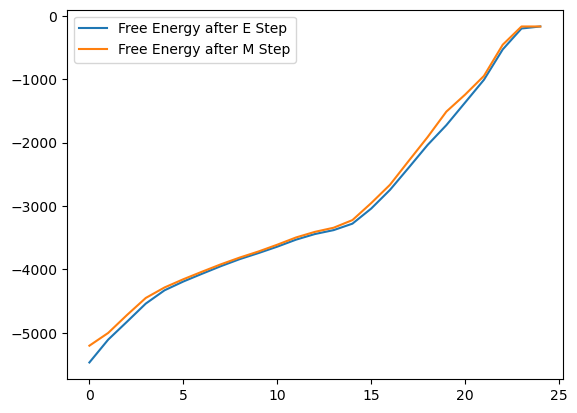

In [167]:
plt.figure()
plt.plot(E_Fs, label='Free Energy after E Step')
plt.plot(M_Fs, label='Free Energy after M Step')
plt.legend()
plt.show()

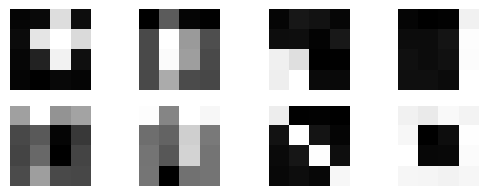

In [170]:
for k in range(K):
    plt.subplot(4, 4, k + 1)
    plt.imshow(np.reshape(loopyEP.mu.T[k], (4, 4)), cmap=plt.gray(), interpolation='none')
    plt.axis('off')

plt.show()